In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
from catboost import CatBoostClassifier, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
ROOT_DIR = Path.cwd().resolve().parent.parent
DATA_DIR = ROOT_DIR / 'data'

logs = pd.read_csv(DATA_DIR / 'log_pk_abitur2.txt', sep=';')
docs = pd.read_excel(DATA_DIR / 'Подача документов.xlsx')
origs = pd.read_excel(DATA_DIR / 'Оригиналы.xlsx')
enrollment = pd.read_excel(DATA_DIR / 'Зачисление.xlsx')
achievements = pd.read_excel(DATA_DIR / 'ИД.xlsx')
info = pd.read_excel(DATA_DIR / 'Информация по абитуриенту.xlsx')
benefits = pd.read_excel(DATA_DIR / 'Льготы.xlsx')
olympiads = pd.read_excel(DATA_DIR / 'Олимпиады.xlsx')
trials = pd.read_excel(DATA_DIR / 'ВИ.xlsx')
exams = pd.read_excel(DATA_DIR / 'ЕГЭ.xlsx')

In [4]:
# Ограничение временного интервала приемной комиссии
docs_cleaned = docs[(docs['ts_abitur'] >= '2024-06-25') & (docs['ts_abitur'] < '2024-07-26')]

In [5]:
base = docs_cleaned[['abitur_kod', 'y']].drop_duplicates().reset_index(drop=True)

In [6]:
# дата отсчёта = 25 июня соответствующего года
ref = {2023: pd.Timestamp('2023-06-25'),
       2024: pd.Timestamp('2024-06-25')}

info['ref_date'] = info['y'].map(ref)
info['age'] = ((info['ref_date'] - info['data_rogdenia'])
               .dt.days/365.25).astype(int)

demo = info[['abitur_kod','y','age','pol_kod', 'pasp_gorod','fact_gorod']]


In [7]:
ege = exams.groupby(["abitur_kod", "y"], as_index=False)["ball"].mean().rename(columns={"ball": "mean_ege"})

In [8]:
WEIGHTS = {
    'Призер регионального этапа':         0.5,
    'Призер (Диплом 2 степени)':          1,
    'Призер (Диплом 3 степени)':          1.5,
    'Победитель (Диплом 1 степени)':      2,
    'Победитель регионального этапа':     3,
    'Призер заключительного этапа':       4,
    'Победитель заключительного этапа':   5,
}

olympiads['weight'] = olympiads['olimp_diplom_name'].map(WEIGHTS).fillna(0)
olympiads_score = (olympiads.groupby(['abitur_kod','y'], as_index=False)
                     .weight.sum()
                     .rename(columns={'weight':'olympiad_score'}))


In [9]:
ach = (achievements.groupby(['abitur_kod','y'], as_index=False)
           .ball.sum()
           .rename(columns={'ball':'sum_ach'}))
ach['sum_ach'] = ach['sum_ach'].clip(upper=10)   # максимум 10


In [10]:
vi = (trials.groupby(['abitur_kod','y'], as_index=False)
              .ball.mean()
              .rename(columns={'ball':'mean_vi'}))


In [11]:
dfs = [demo, ege, olympiads_score, ach, vi]

for tbl in dfs:
    base = base.merge(tbl, on=['abitur_kod','y'], how='left')

base[['pasp_gorod', 'fact_gorod']] = base[['pasp_gorod', 'fact_gorod']].fillna('-')
base  = base.fillna(0)
base = base[base["mean_ege"] > 0]
base['total_score'] = base["mean_ege"] + (base["sum_ach"] / 3)
base = base.drop(columns=["mean_ege", "sum_ach"])
base

,abitur_kod,y,age,pol_kod,pasp_gorod,fact_gorod,olympiad_score,mean_vi,total_score
0,657355,2024,17,1,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,62.333333
1,657243,2024,18,1,Большое Исаково п,Санкт-Петербург г,0.0,0.0,83.333333
2,657352,2024,18,1,Хабаровск г,Санкт-Петербург г,0.0,0.0,45.750000
4,657356,2024,17,2,Салазгорь с,Санкт-Петербург г,0.0,0.0,70.333333
5,657359,2024,18,1,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,50.000000
...,...,...,...,...,...,...,...,...,...
8420,656426,2024,18,2,Верхняя Салда г,Санкт-Петербург г,0.0,0.0,86.083333
8421,656424,2024,18,1,Кострома г,Санкт-Петербург г,0.0,0.0,78.000000
8422,656425,2024,18,2,Бегуницы д,Санкт-Петербург г,0.0,0.0,65.666667
8424,656419,2024,18,1,Подольск г,Санкт-Петербург г,0.0,0.0,56.416667


In [12]:
logs['submitted'] = np.where((logs['is_epgu_orig_doc'] == 1) | (logs['is_orig_doc'] == 1) | (logs['orig_doc_epgu_status'] == 1), 1, 0)
logs['date'] = np.where(
    logs['epgu_orig_doc_upd_ts'].notna(),
    logs['epgu_orig_doc_upd_ts'],
    np.where(
        logs['orig_doc_change_ts'].notna(),
        logs['orig_doc_change_ts'],
        np.where(
            logs['orig_doc_d'].notna(),
            logs['orig_doc_d'],
            logs['reg_ts']
        )
    )
)

logs['date'] = pd.to_datetime(logs['date'], format="%d.%m.%Y %H:%M:%S")

# Фильтрация логов
logs = logs[
    (logs['date'] >= "2024-06-25") &
    (logs['date'] < "2024-08-04") &
    (logs['_oper_type'].str.lower() != 'delete') & # без операций удаления
    (logs['filial_kod'] == 1) & # только главный филиал
    (logs['reg_nom'] >= 0) &
    (logs['zayav_type_kod'] == 1) & # бакалавриат и специалитет
    (logs['priem_type_kod'] == 1) # приемная кампания 1 курс
].sort_values(["abitur_kod", "date"])

# Определение подачи и отзыва оригиналов документов
logs['prev_submitted'] = logs.groupby('abitur_kod')['submitted'].shift(1).fillna(0).astype(int)
conditions = [
    (logs['prev_submitted'] == 0) & (logs['submitted'] == 1),
    (logs['prev_submitted'] == 1) & (logs['submitted'] == 0)
]
choices = ['in', 'out']
logs['transition'] = np.select(conditions, choices, default=None)
logs = logs[logs["transition"].notna()]
filtered_logs = logs[["abitur_kod", "date", "transition"]].reset_index(drop=True)

In [13]:
merged = base.merge(filtered_logs, on='abitur_kod', how='left').reset_index(drop=True)
merged = merged.drop(columns=["y"])

In [14]:
merged

,abitur_kod,age,pol_kod,pasp_gorod,fact_gorod,olympiad_score,mean_vi,total_score,date,transition
0,657355,17,1,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,62.333333,NaT,NaN
1,657243,18,1,Большое Исаково п,Санкт-Петербург г,0.0,0.0,83.333333,NaT,NaN
2,657352,18,1,Хабаровск г,Санкт-Петербург г,0.0,0.0,45.750000,NaT,NaN
3,657356,17,2,Салазгорь с,Санкт-Петербург г,0.0,0.0,70.333333,NaT,NaN
4,657359,18,1,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,50.000000,NaT,NaN
...,...,...,...,...,...,...,...,...,...,...
7621,656426,18,2,Верхняя Салда г,Санкт-Петербург г,0.0,0.0,86.083333,NaT,NaN
7622,656424,18,1,Кострома г,Санкт-Петербург г,0.0,0.0,78.000000,NaT,NaN
7623,656425,18,2,Бегуницы д,Санкт-Петербург г,0.0,0.0,65.666667,NaT,NaN
7624,656419,18,1,Подольск г,Санкт-Петербург г,0.0,0.0,56.416667,2024-08-02 10:21:05,in


In [15]:
SNAP_TS = pd.Timestamp('2024-07-27 00:00:00')
END_TS = pd.Timestamp('2024-08-03 12:00:00')

In [16]:
hist = logs[logs['date'] < SNAP_TS].groupby('abitur_kod').agg(n_in_before = ('transition', lambda x: (x == "in").sum()),
                                                              n_out_before = ('transition', lambda x: (x == 'out').sum()),
                                                              last_move = ('date', 'max')).reset_index()

hist['days_since_last_move'] = (SNAP_TS - hist['last_move']).dt.days
hist = hist.drop(columns='last_move')
hist

,abitur_kod,n_in_before,n_out_before,days_since_last_move
0,644913,2,2,24
1,644921,1,0,4
2,645156,1,0,22
3,645172,1,0,7
4,645226,1,0,0
...,...,...,...,...
398,660230,1,0,1
399,660304,1,0,0
400,660420,1,0,0
401,660583,1,0,0


In [17]:
feat_cols = ['abitur_kod', 'age', 'pol_kod', 'pasp_gorod', 'fact_gorod', 'olympiad_score', 'mean_vi', 'total_score']
features = merged.sort_values(['abitur_kod', 'date']).drop_duplicates('abitur_kod', keep='first')[feat_cols].reset_index(drop=True)

In [18]:
features = features.merge(hist, on='abitur_kod', how='left').fillna({'n_in_before': 0, 'n_out_before': 0, 'days_since_last_move': 999})

In [19]:
features['had_orig_before'] = (features['n_in_before'] > 0).astype(int)
features['orig_status'] = features['n_in_before'] - features['n_out_before']
features["rank"] = features["total_score"].rank(method='first', ascending=False).astype(int)
features = features.sort_values('rank').reset_index(drop=True)
features

,abitur_kod,age,pol_kod,pasp_gorod,fact_gorod,olympiad_score,mean_vi,total_score,n_in_before,n_out_before,days_since_last_move,had_orig_before,orig_status,rank
0,652843,18,2,Ростов-на-Дону г,-,0.0,0.0,101.000000,0.0,0.0,999.0,0,0.0,1
1,647150,17,2,Севастополь г,Санкт-Петербург г,0.0,0.0,100.333333,1.0,0.0,13.0,1,1.0,2
2,646673,18,2,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,100.000000,1.0,0.0,22.0,1,1.0,3
3,649941,18,1,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,99.666667,0.0,0.0,999.0,0,0.0,4
4,655145,18,2,Кингисепп г,Санкт-Петербург г,0.0,0.0,99.333333,0.0,0.0,999.0,0,0.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7254,649534,18,2,Благовещенск г,Санкт-Петербург г,0.0,0.0,22.000000,0.0,0.0,999.0,0,0.0,7255
7255,655383,19,1,Санкт-Петербург г,Санкт-Петербург г,0.0,63.5,20.000000,1.0,0.0,0.0,1,1.0,7256
7256,655528,18,2,Хандагайты с,Санкт-Петербург г,0.0,0.0,19.000000,0.0,0.0,999.0,0,0.0,7257
7257,659920,19,2,-,Санкт-Петербург г,0.0,0.0,16.166667,0.0,0.0,999.0,0,0.0,7258


In [20]:
snap_state = logs[logs['date'] <= SNAP_TS].sort_values(["abitur_kod", "date"]).groupby('abitur_kod').tail(1).set_index('abitur_kod')['submitted'].rename('status_snap')
end_state = logs[logs['date'] <= END_TS].sort_values(["abitur_kod", "date"]).groupby("abitur_kod").tail(1).set_index('abitur_kod')['submitted'].rename('status_end')
label_df = pd.concat([snap_state, end_state], axis=1).fillna(0).astype(int).reset_index()
label_df

,abitur_kod,status_snap,status_end
0,644913,0,0
1,644921,1,1
2,645156,1,1
3,645172,1,0
4,645226,1,1
...,...,...,...
1182,663012,0,1
1183,663013,0,1
1184,663016,0,1
1185,663017,0,1


In [21]:
def decide(row) -> int:
    s0, sf = row.status_snap, row.status_end
    if s0 == 1 and sf == 1:
        return 3 # stay
    if s0 == 0 and sf == 1:
        return 2 # come
    if s0 == 1 and sf == 0:
        return 1 # revoke
    else:
        return 0 # never_came

In [22]:
label_df['target'] = label_df.apply(decide, axis=1).astype(int)
features = features.merge(label_df[['abitur_kod', 'target']], on='abitur_kod', how='left')
features['target'] = features['target'].fillna(0)

In [23]:
features.to_csv(DATA_DIR / "train_data_task2.csv", index=False)

In [24]:
calls = pd.read_excel(DATA_DIR / 'обзвон ПМиИ (24.07.2024).xlsx')

calls = calls.dropna(how='all')
calls['Звонок'] = calls['Звонок'].fillna(0)
calls = calls[['I+2:799D', 'СУММА', 'ПРИОРИТЕТ', 'Фактическое поступление', 'Звонок', 'Вердикт по звонку']]
calls['Вердикт по звонку'].fillna(0, inplace=True)
calls = calls.sort_values(by=['I+2:799D', 'ПРИОРИТЕТ']).drop_duplicates(subset=['I+2:799D'])[:-1]
calls = calls.sort_values(by='СУММА', ascending=False).reset_index(drop=True)
calls = calls.rename(columns={'I+2:799D':'abitur_kod',
                              'СУММА':'total_score',
                              'ПРИОРИТЕТ':'prior',
                              'Фактическое поступление':'call_fact',
                              'Звонок':'call_made',
                              'Вердикт по звонку':'call_verdict'})
calls = calls.astype(int)
calls

,abitur_kod,total_score,prior,call_fact,call_made,call_verdict
0,657505,305,1,0,0,0
1,660134,301,1,0,0,0
2,649335,298,1,0,0,0
3,659563,297,1,0,0,0
4,654183,295,2,0,1,-1
...,...,...,...,...,...,...
777,646663,0,3,0,0,0
778,656141,0,4,0,0,0
779,659649,0,1,0,1,0
780,645434,0,5,0,0,0


In [25]:
SEATS_RAW = {
    'Бизнес-информатика': 8,
    'Гостиничное дело': 9,
    'Государственное и муниципальное управление': 8,
    'Зарубежное регионоведение': 3,
    'Информационные системы и технологии': 16,
    'Менеджмент': 54,
    'Прикладная информатика': 15,
    'Прикладная математика и информатика': 60,
    'Сервис': 24,
    'Социология': 37,
    'Торговое дело': 11,
    'Туризм': 20,
    'Управление качеством': 14,
    'Управление персоналом': 8,
    'Экономика': 47,
}

static_feats = features.copy()
static_feats = static_feats.drop(columns=['orig_status', 'n_in_before', 'n_out_before', 'days_since_last_move', 'had_orig_before', 'target'])

choices = docs_cleaned[docs_cleaned['ob_osnova_name'] == "Бюджет"][['abitur_kod', 'grp_spec_name', 'prior']].drop_duplicates()

median = int(np.median(list(SEATS_RAW.values())))

In [26]:
def make_snap(snap_ts: pd.Timestamp) -> pd.DataFrame:
    status = logs.query('date <= @snap_ts').sort_values(['abitur_kod', 'date']).groupby('abitur_kod').tail(1).set_index('abitur_kod')['submitted'].rename('orig_status')
    hist = logs.query('date < @snap_ts').groupby('abitur_kod').agg(n_in_before  = ('transition', lambda s: (s=="in").sum()),
                                                                   n_out_before = ('transition', lambda s: (s=="out").sum()),
                                                                   last_move    = ('date','max')).reset_index()
    hist['days_since_last_move'] = (snap_ts - hist['last_move']).dt.days
    hist = hist.drop(columns='last_move')

    out = (static_feats
           .merge(status, on='abitur_kod', how='left')
           .merge(hist, on='abitur_kod', how='left')
           .merge(calls[['abitur_kod', 'call_made', 'call_verdict']], on='abitur_kod', how='left')
           .fillna({'orig_status':0, 'n_in_before':0, 'n_out_before':0, 'days_since_last_move':999, 'call_made':0, 'call_verdict':0})
           .assign(had_orig_before=lambda r: (r['n_in_before'] > 0).astype(int))
           )
    
    return out

def allocate_seats(choices: pd.DataFrame, snap: pd.DataFrame) -> pd.DataFrame:
    data = choices.merge(snap[['abitur_kod', 'orig_status', 'total_score']], on='abitur_kod', how='left').assign(passes_now=0)
    data = data.sort_values(['prior', 'grp_spec_name', 'total_score', 'abitur_kod'], ascending=[True, True, False, True])
    data['blocked'] = 0
    for pr in sorted(data['prior'].unique()):
        layer = data.query("(prior == @pr) & (orig_status == 1) & (passes_now == 0) & (blocked == 0)")
        for spec, sub in layer.groupby('grp_spec_name'):
            quota = SEATS_RAW.get(spec, median) - data.query('grp_spec_name == @spec & passes_now == 1').shape[0]
            if quota <= 0:
                continue
            winners = sub.head(quota).index
            data.loc[winners, 'passes_now'] = 1
        passed_ids = data.loc[data['passes_now'] == 1, 'abitur_kod'].unique()
        data.loc[(data['abitur_kod'].isin(passed_ids)) & (data['passes_now'] == 0), 'blocked'] = 1
    return data.drop(columns='blocked')

def build_df(target_dir: str, snap_ts, end_ts) -> pd.DataFrame:
    snap = make_snap(snap_ts)

    df_dir = choices.query('grp_spec_name == @target_dir').merge(snap, on='abitur_kod').sort_values('total_score', ascending=False)
    df_dir['dir_rank'] = df_dir.groupby('grp_spec_name')['total_score'].rank(method='first', ascending=False).astype(int)

    full_choices = allocate_seats(choices, snap)
    df_dir = df_dir.merge(full_choices[['abitur_kod', 'grp_spec_name', 'passes_now']], on=['abitur_kod', 'grp_spec_name'], how='left')
    
    status_end = logs.query('date <= @end_ts').sort_values(['abitur_kod', 'date']).groupby('abitur_kod').tail(1).set_index('abitur_kod')['submitted'].rename('target')
    df_dir = df_dir.merge(status_end, on='abitur_kod', how='left').fillna({'target': 0}).astype({'target': int, 'orig_status': int})

    df_dir = df_dir.sort_values(['prior', 'dir_rank']).drop_duplicates('abitur_kod').reset_index(drop=True)
    df_dir['snapshot'] = snap_ts.date().isoformat()
    return df_dir


In [27]:
TIMES = [
    pd.Timestamp('2024-07-27 23:59:59'),
    pd.Timestamp('2024-07-28 23:59:59'),
    pd.Timestamp('2024-07-29 23:59:59'),
    pd.Timestamp('2024-07-30 23:59:59'),
    pd.Timestamp('2024-07-31 23:59:59'),
    pd.Timestamp('2024-08-01 23:59:59'),
    pd.Timestamp('2024-08-02 23:59:59'),
    pd.Timestamp('2024-08-03 12:00:00'),
]

daily_sets = []
for idx in range(len(TIMES) - 1):
    df_day = build_df('Прикладная математика и информатика', TIMES[idx], TIMES[idx+1])
    df_day['days_elapsed'] = len(daily_sets) + 1
    df_day['days_remained'] = 7 - len(daily_sets)
    daily_sets.append(df_day)

In [28]:
daily_sets[-1]

,abitur_kod,grp_spec_name,prior,age,pol_kod,pasp_gorod,fact_gorod,olympiad_score,mean_vi,total_score,rank,orig_status,n_in_before,n_out_before,days_since_last_move,call_made,call_verdict,had_orig_before,dir_rank,passes_now,target,snapshot,days_elapsed,days_remained
0,659563,Прикладная математика и информатика,1,17,1,Всеволожск г,Санкт-Петербург г,0.0,0.0,99.000000,8,0,0.0,0.0,999.0,0.0,0.0,0,1,0,0,2024-08-02,7,1
1,660134,Прикладная математика и информатика,1,21,1,Красноярск г,Санкт-Петербург г,0.0,0.0,98.833333,9,0,0.0,0.0,999.0,0.0,0.0,0,2,0,0,2024-08-02,7,1
2,650853,Прикладная математика и информатика,1,17,1,Обильное с,Санкт-Петербург г,0.0,0.0,97.333333,28,0,0.0,0.0,999.0,1.0,0.0,0,3,0,0,2024-08-02,7,1
3,654498,Прикладная математика и информатика,1,18,2,Магнитогорск г,Санкт-Петербург г,0.0,0.0,96.666667,40,0,0.0,0.0,999.0,0.0,0.0,0,5,0,0,2024-08-02,7,1
4,649335,Прикладная математика и информатика,1,16,1,Новый Уренгой г,-,0.0,0.0,96.583333,43,0,0.0,0.0,999.0,0.0,0.0,0,7,0,0,2024-08-02,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
721,654539,Прикладная математика и информатика,6,17,2,Новокузнецк г,Санкт-Петербург г,0.0,0.0,78.500000,2682,0,0.0,0.0,999.0,0.0,0.0,0,423,0,0,2024-08-02,7,1
722,653180,Прикладная математика и информатика,6,17,2,Санкт-Петербург г,Санкт-Петербург г,0.0,0.0,76.083333,3069,0,0.0,0.0,999.0,0.0,0.0,0,460,0,0,2024-08-02,7,1
723,653862,Прикладная математика и информатика,6,17,1,Геленджик г,Санкт-Петербург г,0.0,0.0,70.916667,4069,0,0.0,0.0,999.0,0.0,0.0,0,543,0,0,2024-08-02,7,1
724,658916,Прикладная математика и информатика,7,18,2,Санкт-Петербург г,Санкт-Петербург г,1.5,0.0,92.583333,238,0,0.0,0.0,999.0,1.0,-1.0,0,19,0,0,2024-08-02,7,1


              precision    recall  f1-score   support

           0       0.97      1.00      0.99       659
           1       1.00      0.75      0.85        67

    accuracy                           0.98       726
   macro avg       0.99      0.87      0.92       726
weighted avg       0.98      0.98      0.98       726




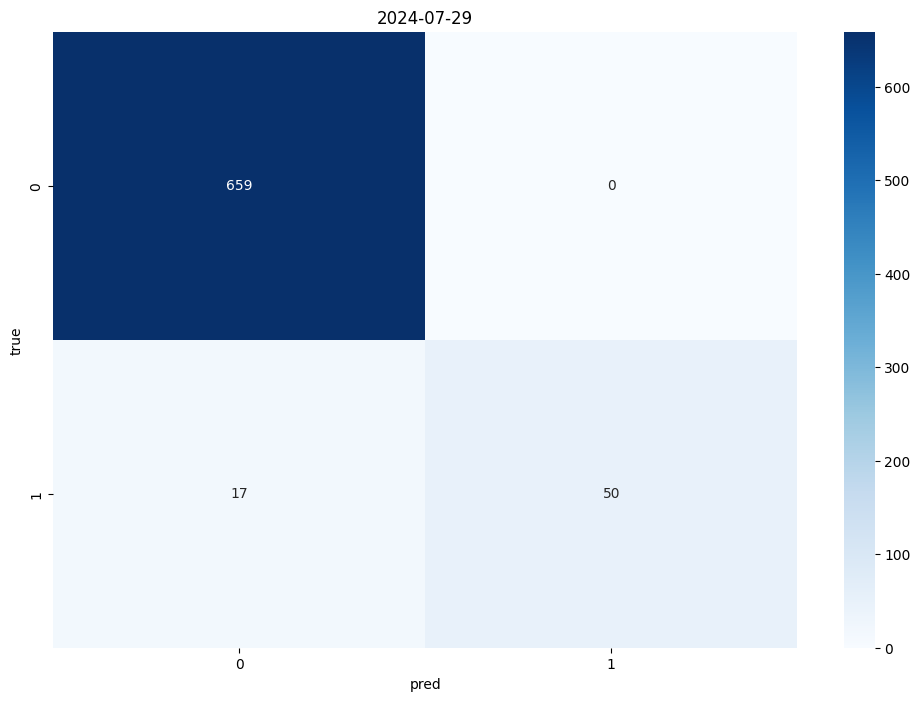

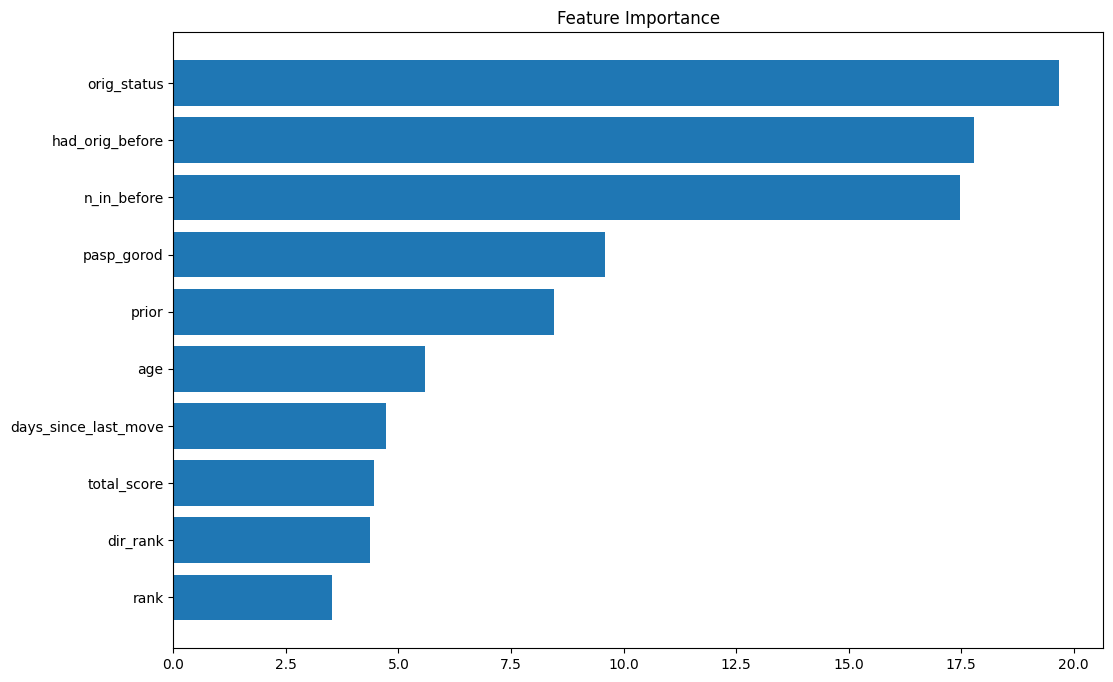

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       633
           1       0.99      0.71      0.82        93

    accuracy                           0.96       726
   macro avg       0.97      0.85      0.90       726
weighted avg       0.96      0.96      0.96       726




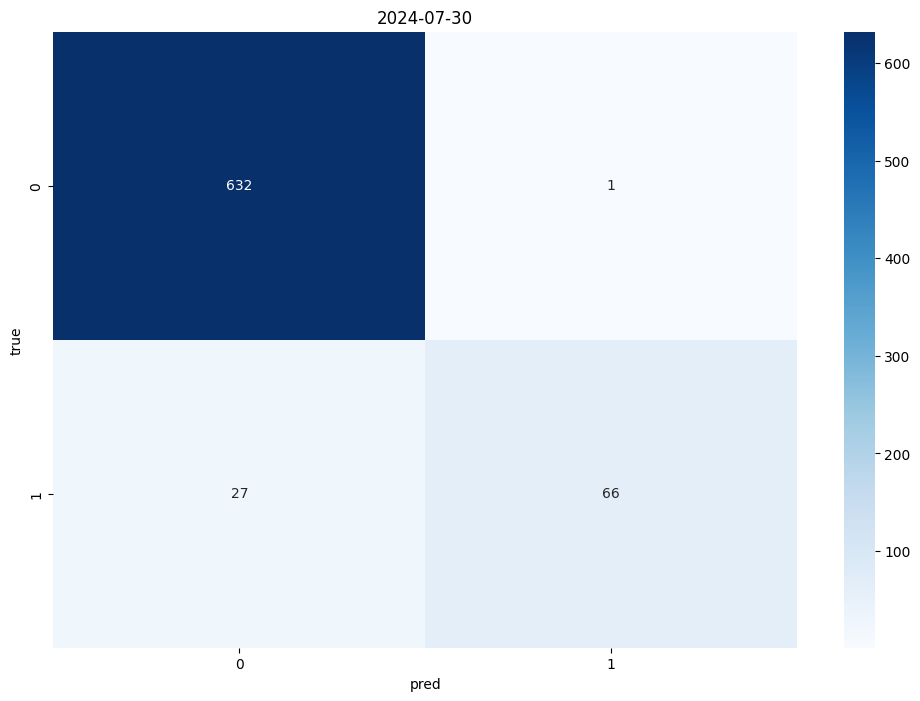

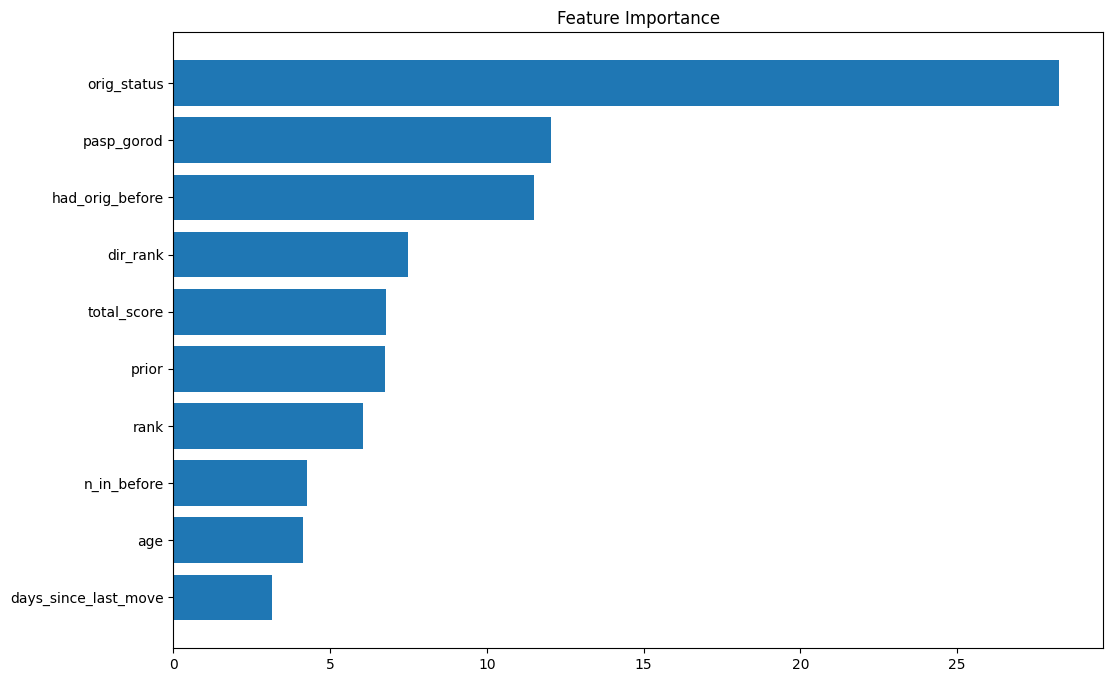

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       627
           1       0.93      0.89      0.91        99

    accuracy                           0.98       726
   macro avg       0.95      0.94      0.95       726
weighted avg       0.97      0.98      0.97       726




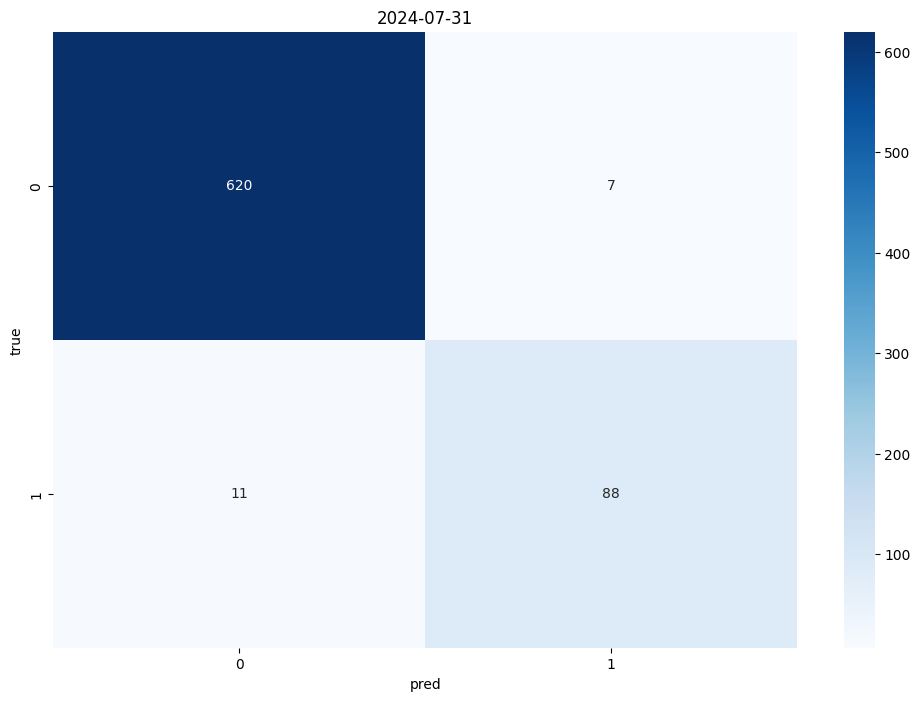

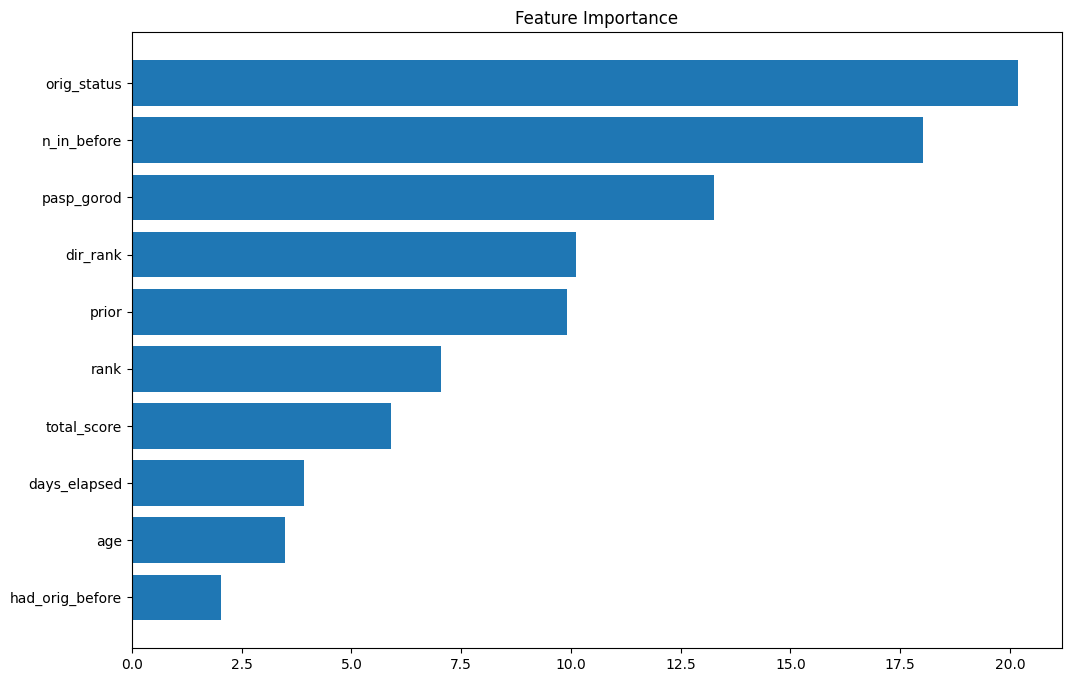

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       611
           1       0.86      0.75      0.80       115

    accuracy                           0.94       726
   macro avg       0.91      0.86      0.88       726
weighted avg       0.94      0.94      0.94       726




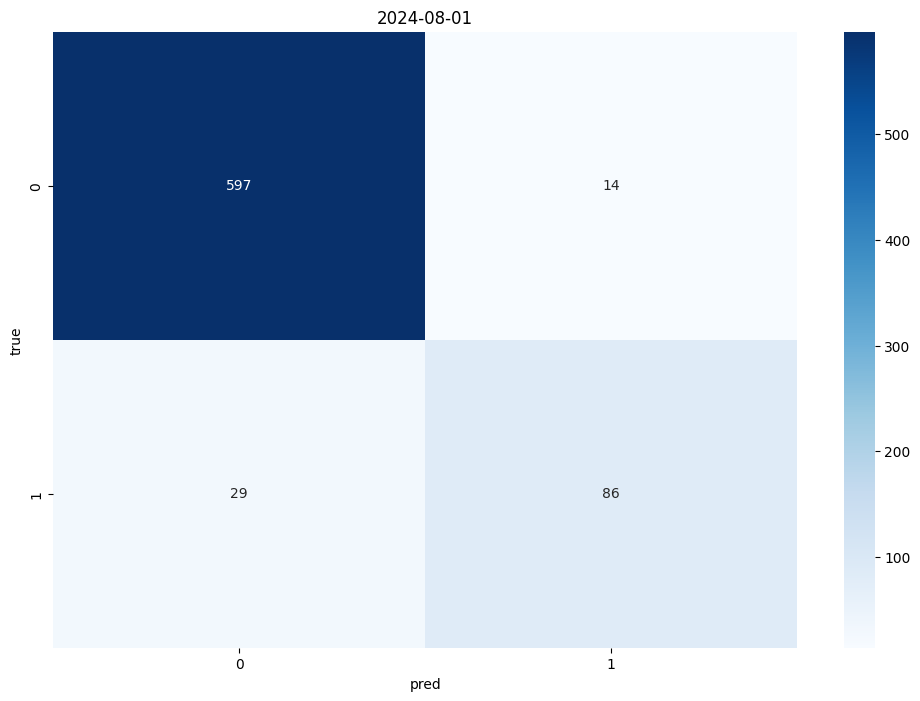

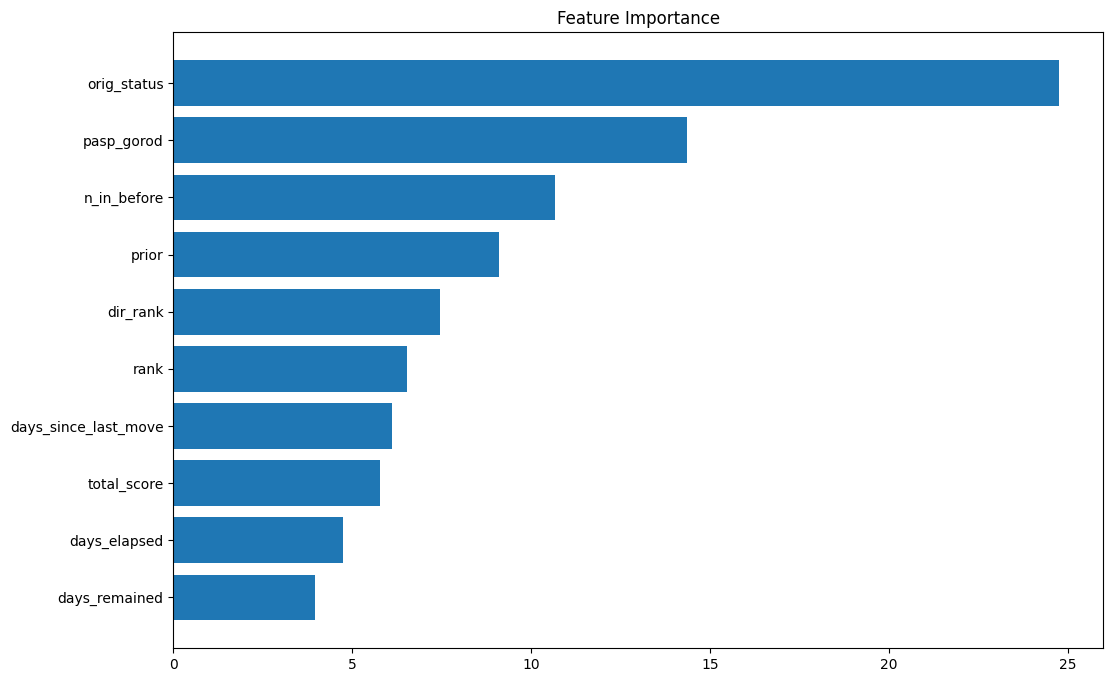

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       605
           1       0.81      0.81      0.81       121

    accuracy                           0.94       726
   macro avg       0.89      0.89      0.89       726
weighted avg       0.94      0.94      0.94       726




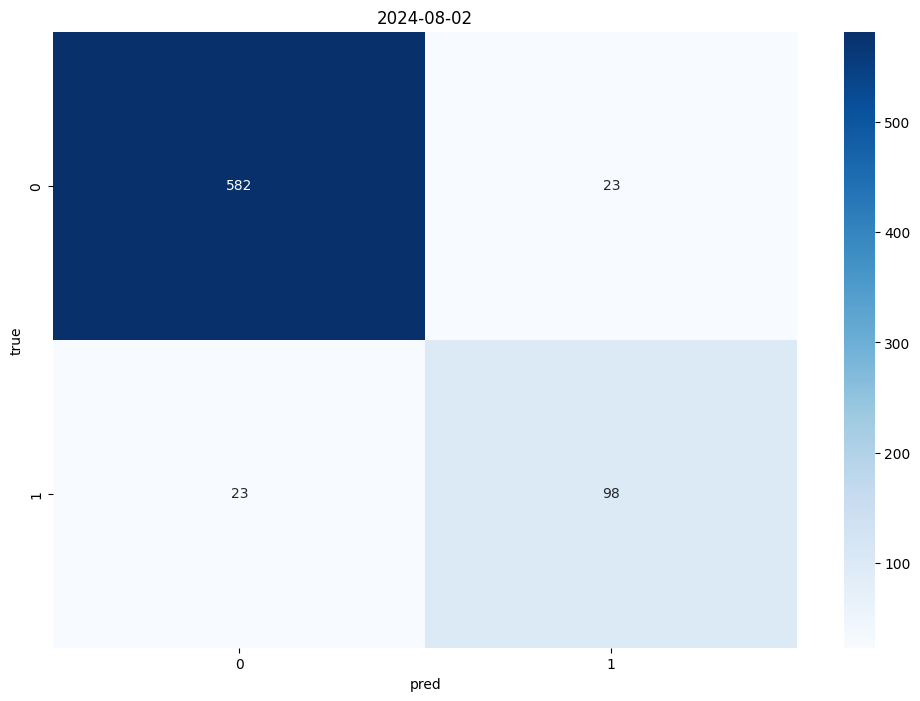

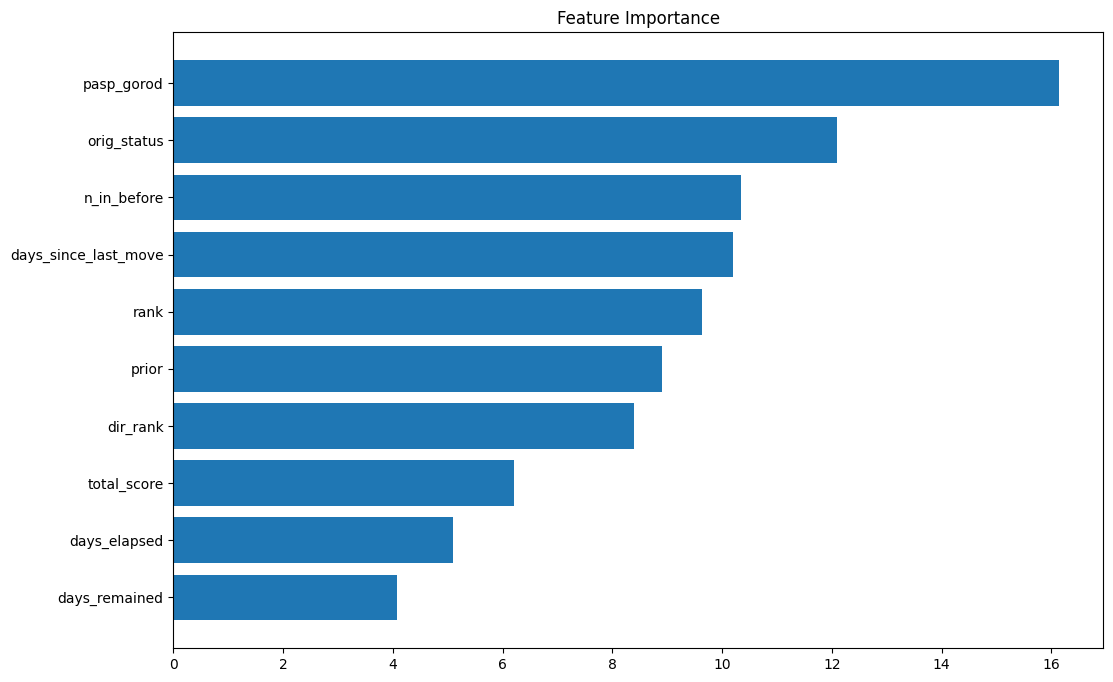

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       604
           1       0.85      0.88      0.86       122

    accuracy                           0.95       726
   macro avg       0.91      0.92      0.92       726
weighted avg       0.95      0.95      0.95       726




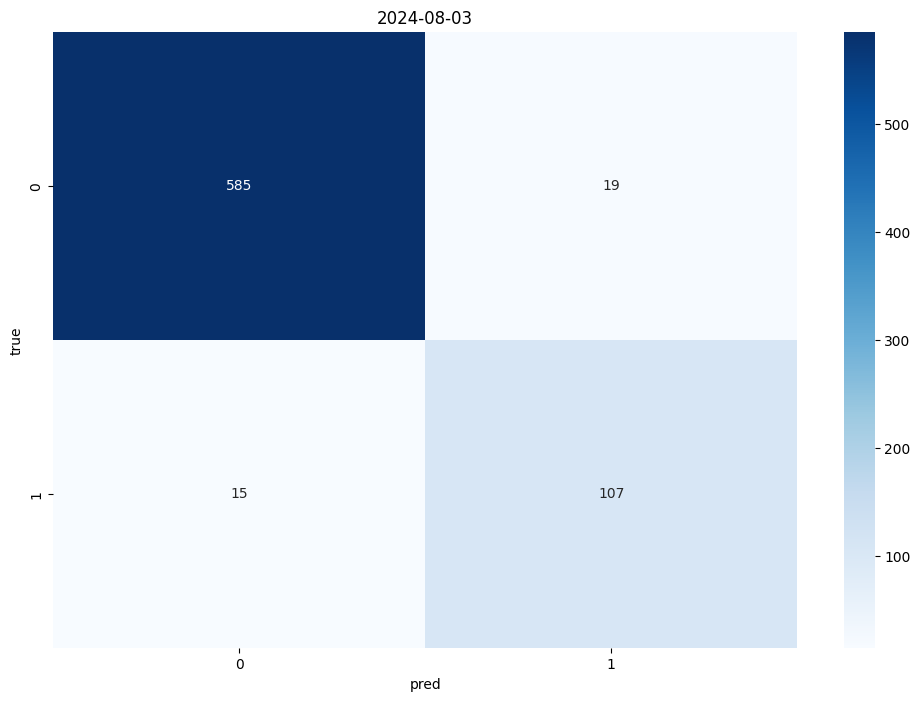

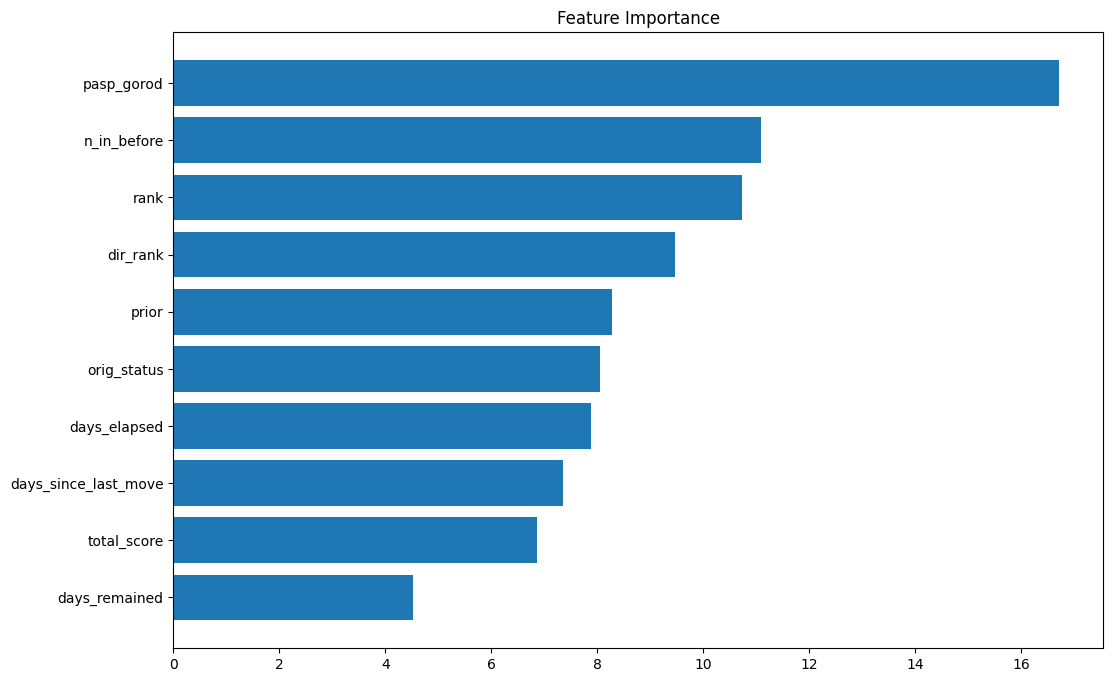

In [29]:
feature_cols = [
    'prior', 'age', 'pol_kod', 'pasp_gorod', 'fact_gorod',
    'olympiad_score', 'mean_vi', 'total_score',
    'n_in_before', 'n_out_before', 'had_orig_before',
    'days_since_last_move', 'dir_rank', 'rank',
    'orig_status', 'passes_now',
    #'call_made', 'call_verdict',
    'days_elapsed', 'days_remained'
]
cat_cols = [
    'prior', 'pol_kod', 'pasp_gorod', 'fact_gorod',
    'orig_status', 'had_orig_before', 'passes_now',
    #'call_made', 'call_verdict'
]

# На всех исторических данных
MODELS = {}

for idx in range(len(daily_sets)-1):
    train_df = pd.concat(daily_sets[:idx+1], ignore_index=True)
    test_df = daily_sets[idx+1]

    X_train = train_df[feature_cols].copy()
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    y_train = train_df['target']

    X_test = test_df[feature_cols].copy()
    X_test[cat_cols] = X_test[cat_cols].astype(str)
    y_test = test_df['target']

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(
        iterations = 1500,
        learning_rate = 0.1,
        subsample = 0.8,
        depth = 3,
        loss_function = "Logloss",
        class_weights = [1, 8],
        eval_metric = "Recall",
        random_state = 42,
        verbose = False,
    )
    model.fit(train_pool)

    y_pred = model.predict(test_pool)
    print(classification_report(y_test, y_pred))
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{TIMES[idx+2].date().isoformat()}')
    plt.xlabel('pred')
    plt.ylabel('true')
    plt.show()

    importances = model.get_feature_importance(train_pool)
    fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False)

    top = fi_df.head(10)[::-1]
    plt.figure(figsize=(12, 8))
    plt.barh(top['feature'], top['importance'])
    plt.title("Feature Importance")
    plt.show()

    MODELS[TIMES[idx+2].date().isoformat()] = {"model": model, "cm": cm}

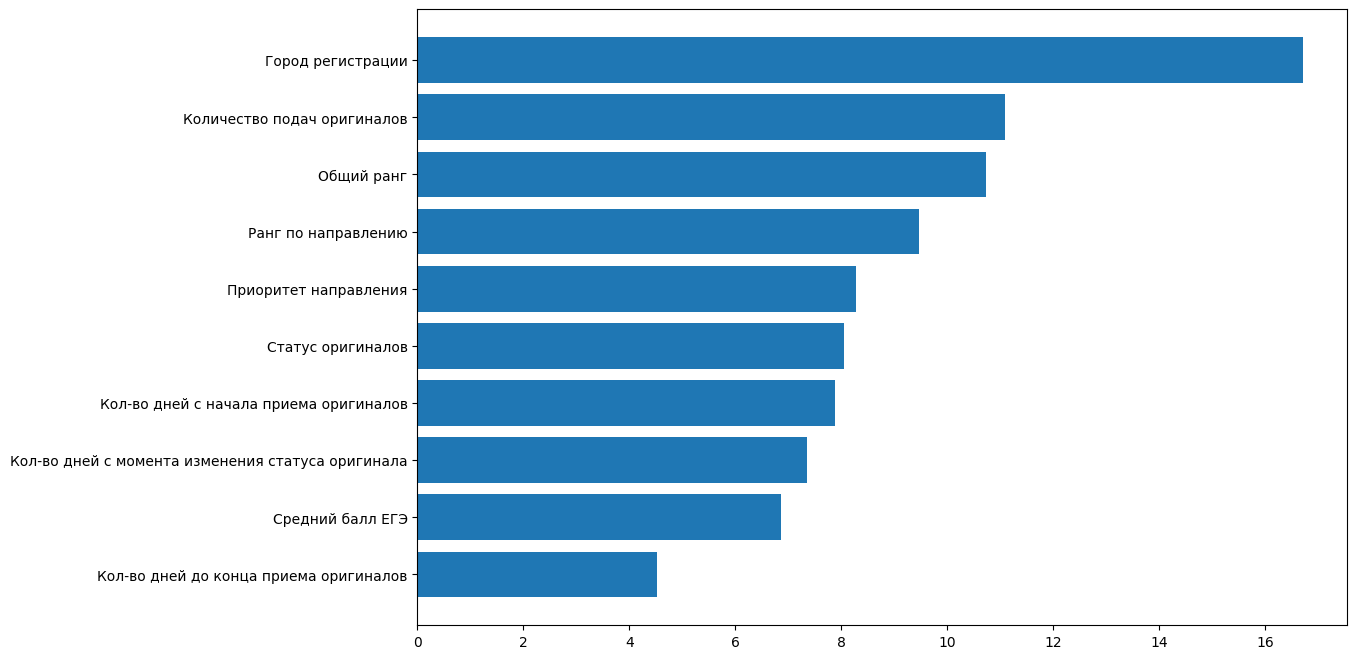

In [30]:
importances = model.get_feature_importance(train_pool)
fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False)
features = ['Город регистрации', 'Количество подач оригиналов', 'Общий ранг', 'Ранг по направлению', 'Приоритет направления', 'Статус оригиналов', 'Кол-во дней с начала приема оригиналов', 'Кол-во дней с момента изменения статуса оригинала', 'Средний балл ЕГЭ', 'Кол-во дней до конца приема оригиналов']

top = fi_df.head(10)[::-1]
plt.figure(figsize=(12, 8))
plt.barh(list(reversed(features)), top['importance'])
plt.show()

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       659
           1       1.00      0.75      0.85        67

    accuracy                           0.98       726
   macro avg       0.99      0.87      0.92       726
weighted avg       0.98      0.98      0.98       726




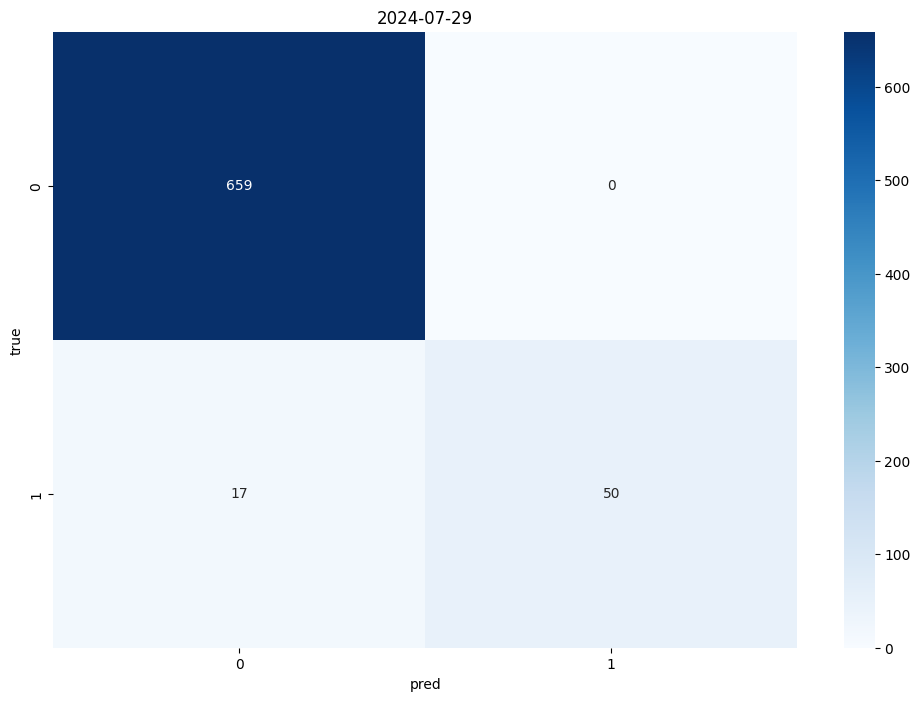

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       633
           1       0.99      0.71      0.82        93

    accuracy                           0.96       726
   macro avg       0.97      0.85      0.90       726
weighted avg       0.96      0.96      0.96       726




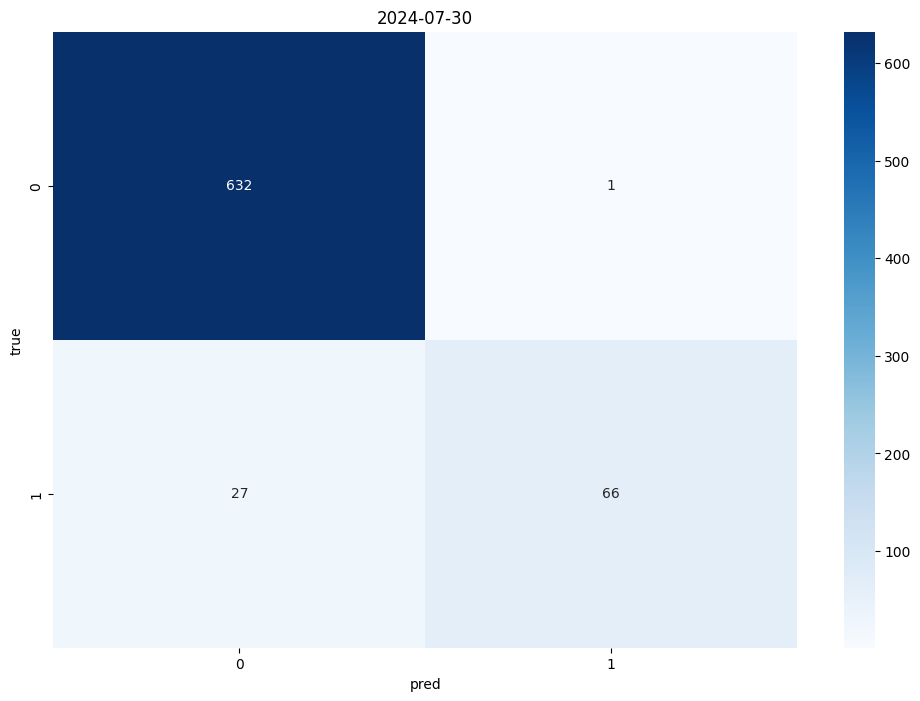

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       627
           1       0.95      0.89      0.92        99

    accuracy                           0.98       726
   macro avg       0.96      0.94      0.95       726
weighted avg       0.98      0.98      0.98       726




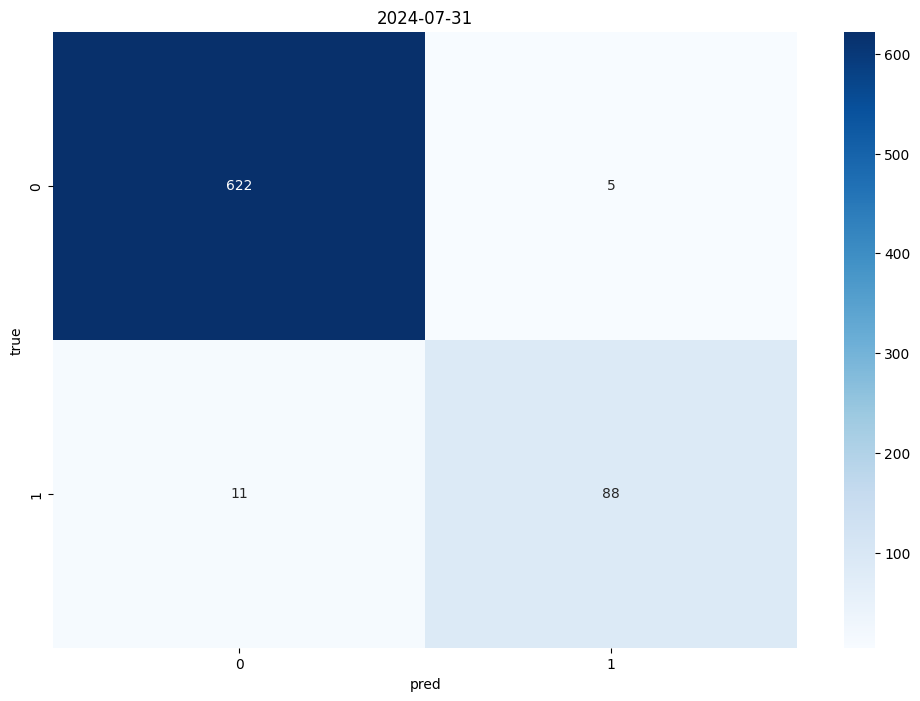

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       611
           1       0.87      0.75      0.80       115

    accuracy                           0.94       726
   macro avg       0.91      0.86      0.88       726
weighted avg       0.94      0.94      0.94       726




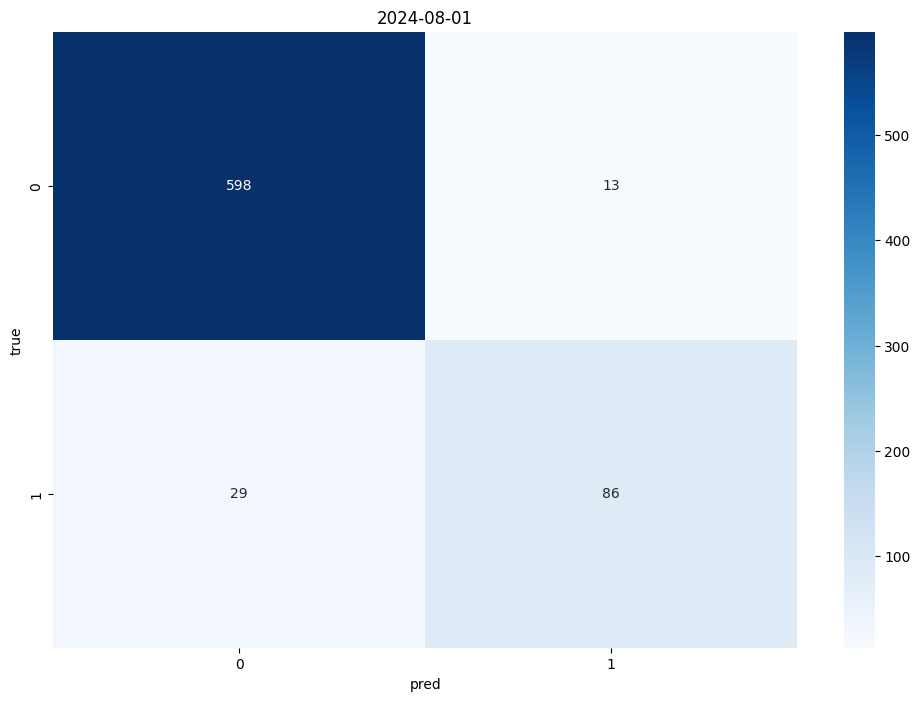

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       605
           1       0.85      0.81      0.83       121

    accuracy                           0.94       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.94      0.94      0.94       726




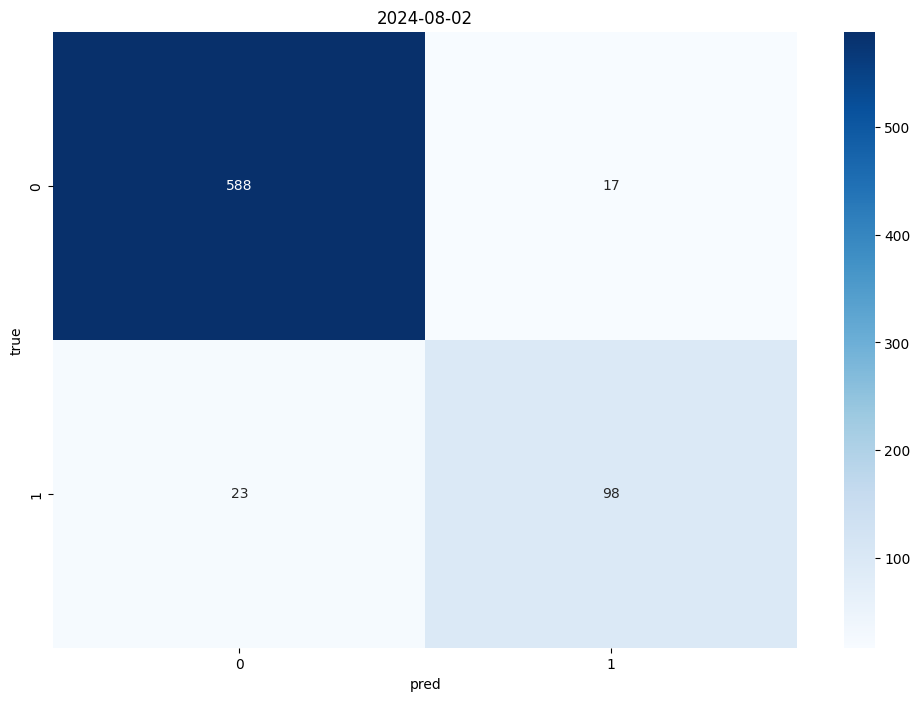

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       604
           1       0.88      0.88      0.88       122

    accuracy                           0.96       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.96      0.96      0.96       726




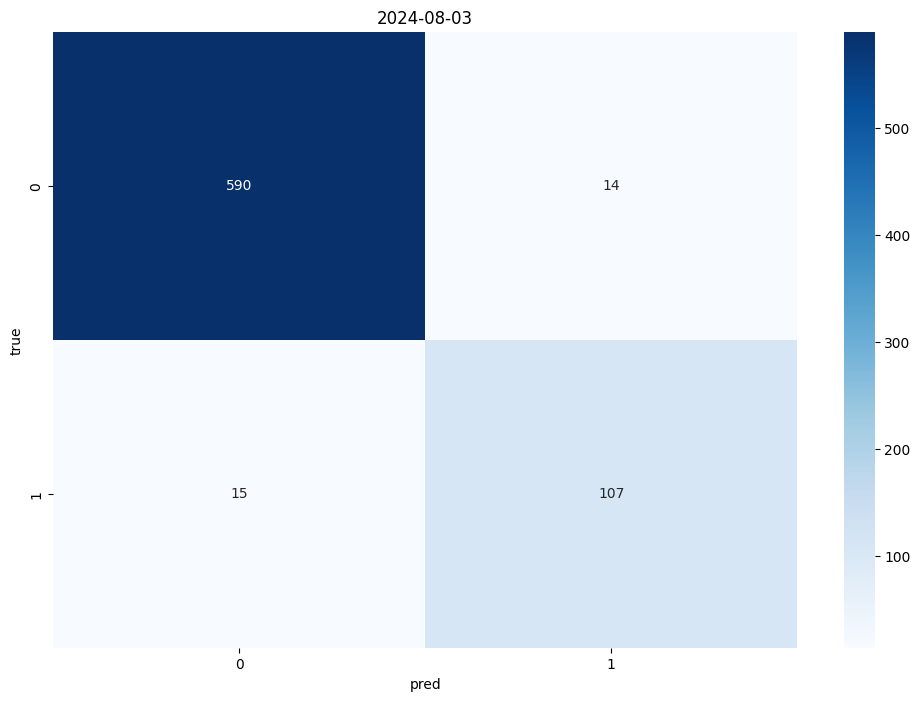

In [31]:
# baseline: завтра такое же, как и сегодня
baseline = {}
for idx in range(len(daily_sets)-1):
    train_df = pd.concat(daily_sets[:idx+1], ignore_index=True)
    test_df  = daily_sets[idx+1]

    X_train = train_df[feature_cols].copy()
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    y_train = train_df['target']

    X_test = test_df[feature_cols].copy()
    X_test[cat_cols] = X_test[cat_cols].astype(str)
    y_test = test_df['target']

    y_pred = X_test['orig_status'].astype(int).values

    print(classification_report(y_test, y_pred))
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{TIMES[idx+2].date().isoformat()}')
    plt.xlabel('pred')
    plt.ylabel('true')
    plt.show()

    baseline[TIMES[idx+2].date().isoformat()] = cm

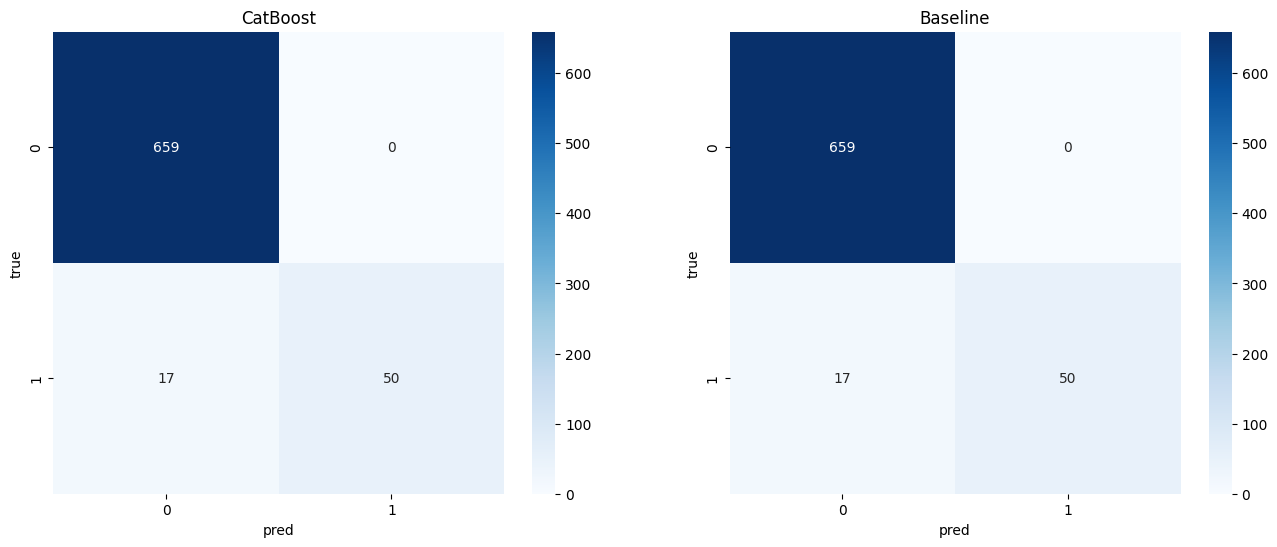

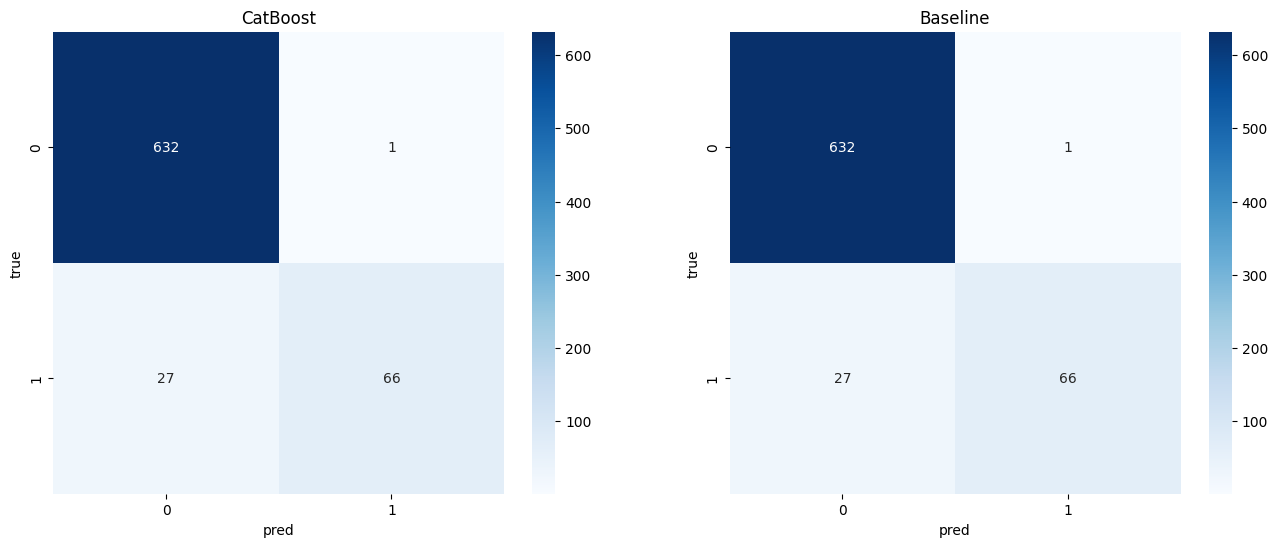

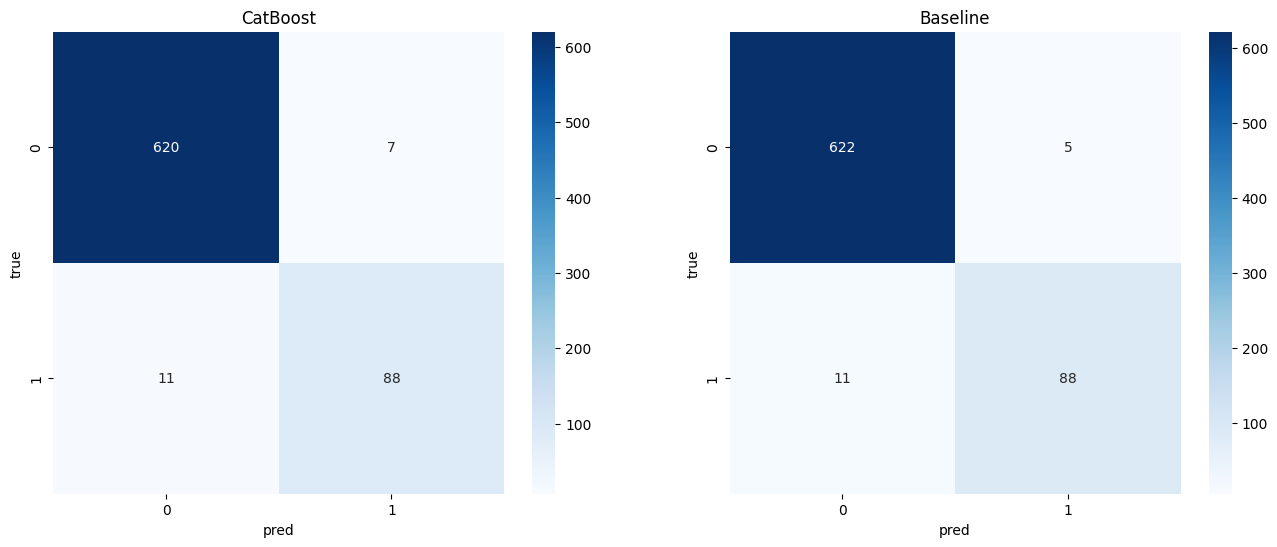

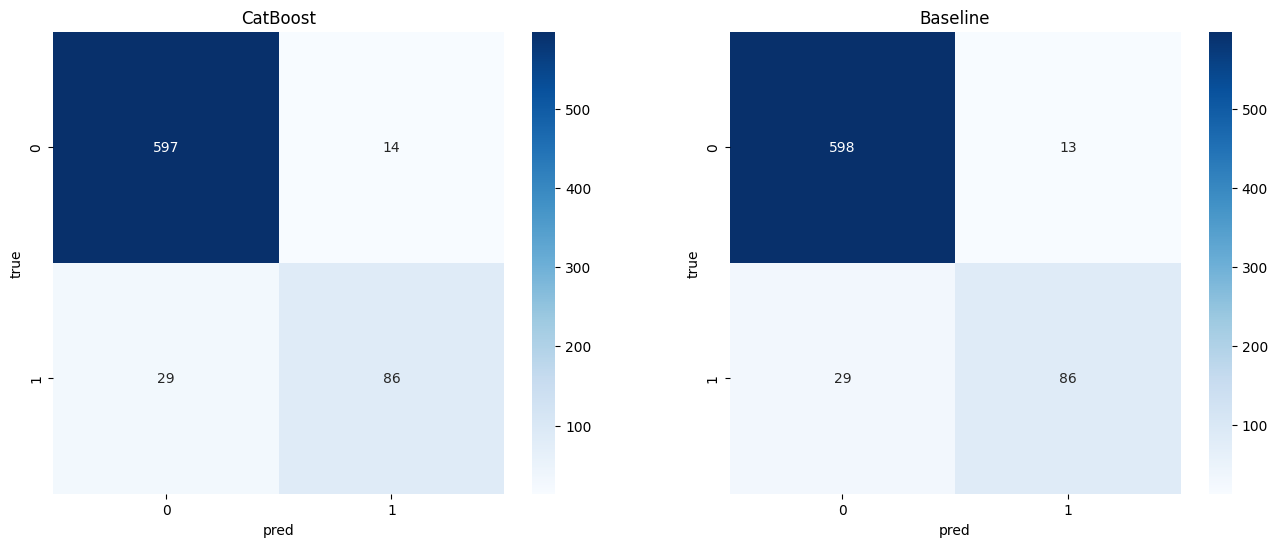

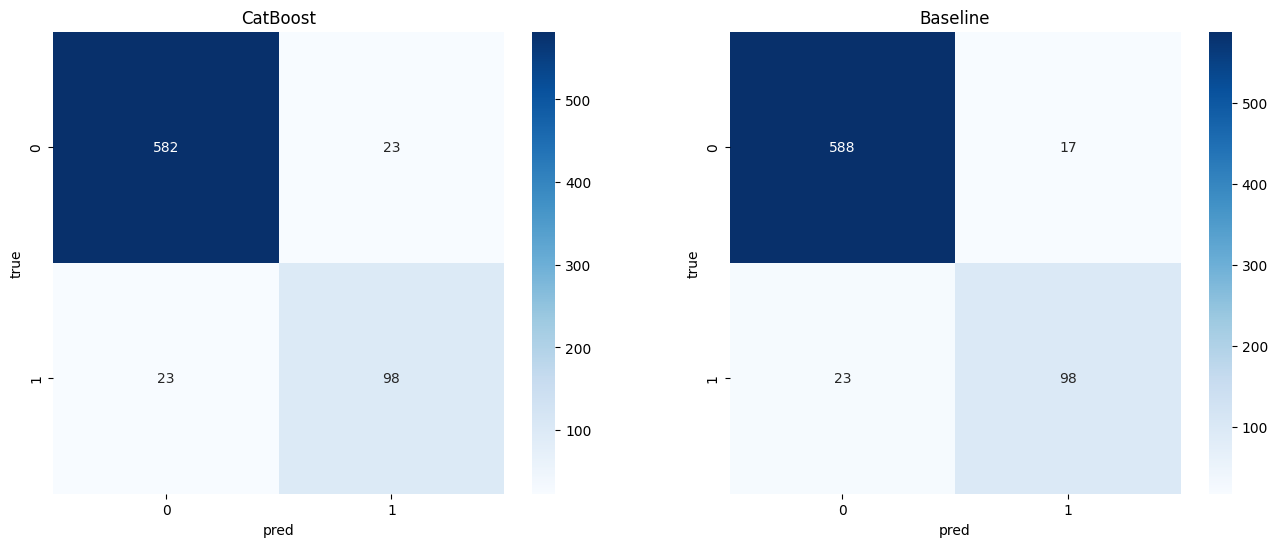

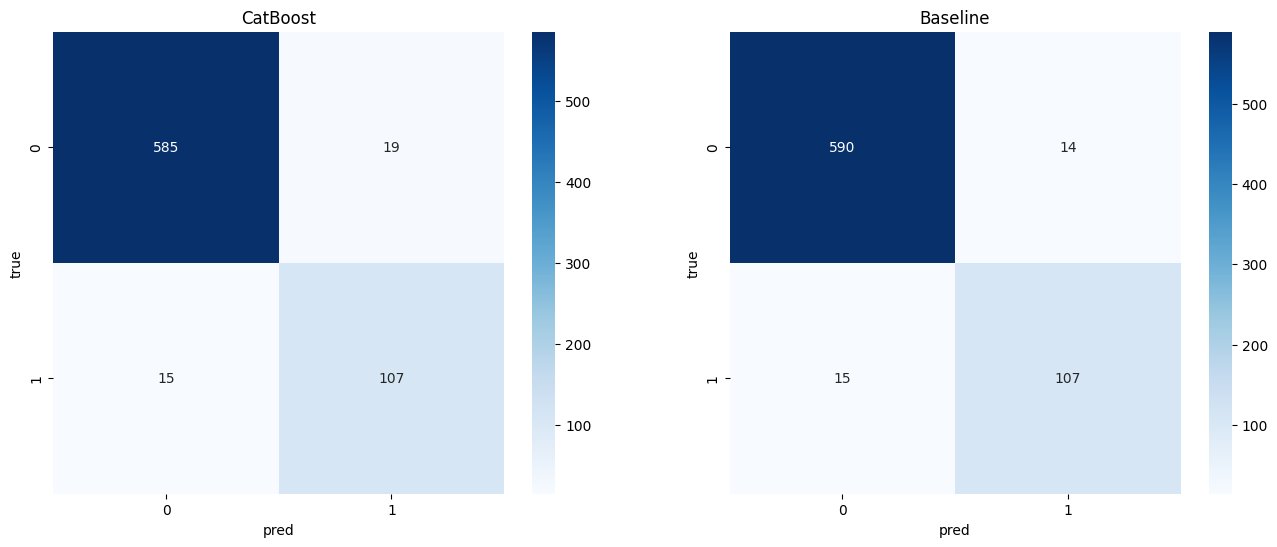

In [32]:
for idx in baseline.keys():
    cm_cb = MODELS[idx]['cm']
    cm_base = baseline[idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm_cb, annot=True, fmt='d', ax=axes[0], cmap='Blues')
    axes[0].set_title('CatBoost')
    axes[0].set_xlabel('pred')
    axes[0].set_ylabel('true')
    sns.heatmap(cm_base, annot=True, fmt='d', ax=axes[1], cmap='Blues')
    axes[1].set_title('Baseline')
    axes[1].set_xlabel('pred')
    axes[1].set_ylabel('true')
    plt.show()

In [76]:
contest = None
for idx in range(1, len(daily_sets)):
    df_day = daily_sets[idx]

    X_day = df_day[feature_cols].copy()
    X_day[cat_cols] = X_day[cat_cols].astype(str)
    test = Pool(X_day, cat_features=cat_cols)

    model = MODELS[TIMES[idx+1].date().isoformat()]['model']

    df_day[f'y_{idx}'] = df_day['target']
    df_day[f'pred_{idx}'] = model.predict(test)
    df_day[f'prob_{idx}'] = model.predict_proba(test)[:, 1]

    keep = ['dir_rank', 'abitur_kod', 'total_score', f'y_{idx}', f'pred_{idx}', f'prob_{idx}']

    if contest is None:
        contest = df_day[keep]
    else:
        if idx != len(daily_sets) - 1:
            contest = contest.merge(df_day[keep], on=['dir_rank', 'abitur_kod', 'total_score'])
        else:
            contest = contest.merge(df_day[keep + ['passes_now']], on=['dir_rank', 'abitur_kod', 'total_score'])

contest = contest.sort_values('dir_rank').reset_index(drop=True)

In [97]:
test = contest[['dir_rank', 'abitur_kod', 'total_score', 'y_5', 'prob_6']]
test[(test['y_5'] == 1) & (test['prob_6'] < 0.9)]

,dir_rank,abitur_kod,total_score,y_5,prob_6
88,89,652366,88.333333,1,0.884710
157,158,656758,85.750000,1,0.508716
309,310,653761,81.666667,1,0.666362
343,344,655732,80.750000,1,0.630538
393,394,654145,79.666667,1,0.897031


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       627
           1       0.93      0.89      0.91        99

    accuracy                           0.98       726
   macro avg       0.95      0.94      0.95       726
weighted avg       0.97      0.98      0.97       726




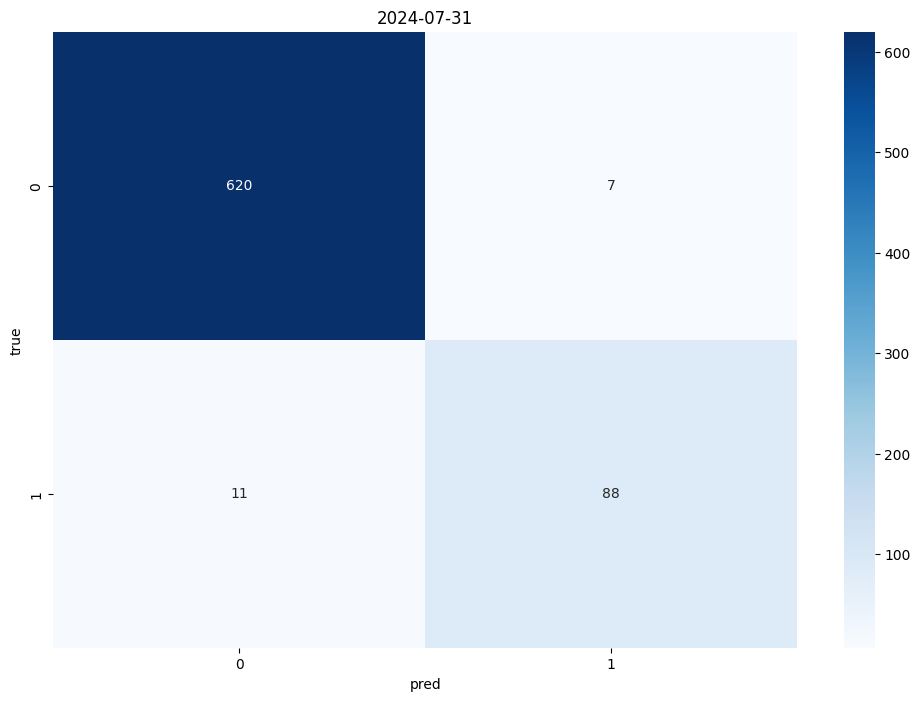

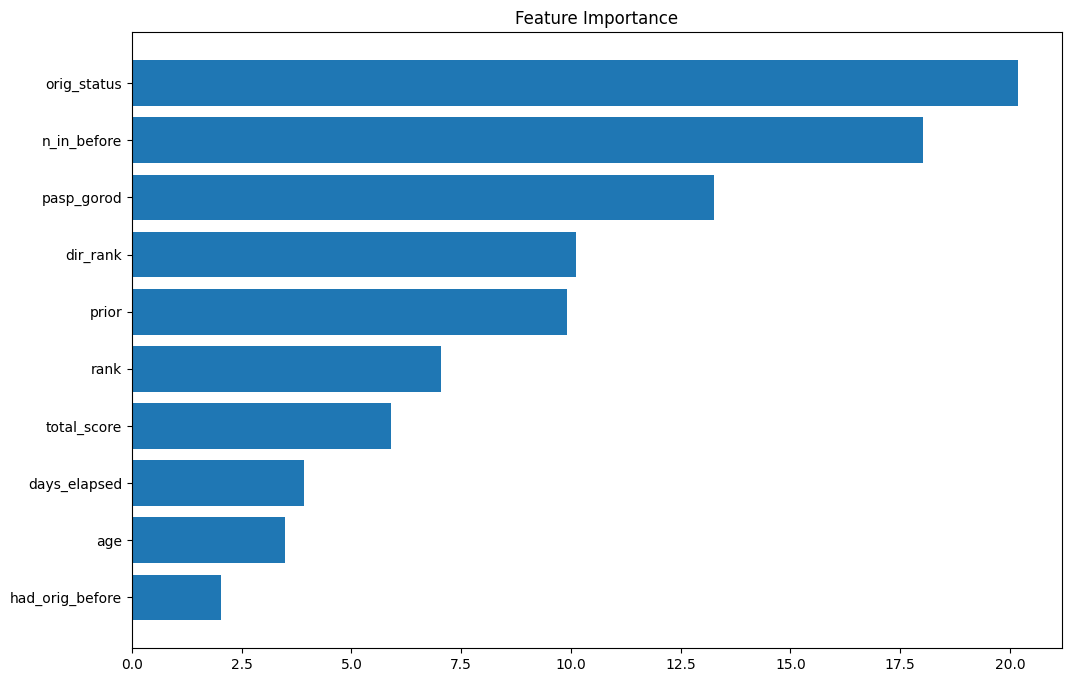

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       611
           1       0.86      0.75      0.80       115

    accuracy                           0.94       726
   macro avg       0.91      0.86      0.88       726
weighted avg       0.94      0.94      0.94       726




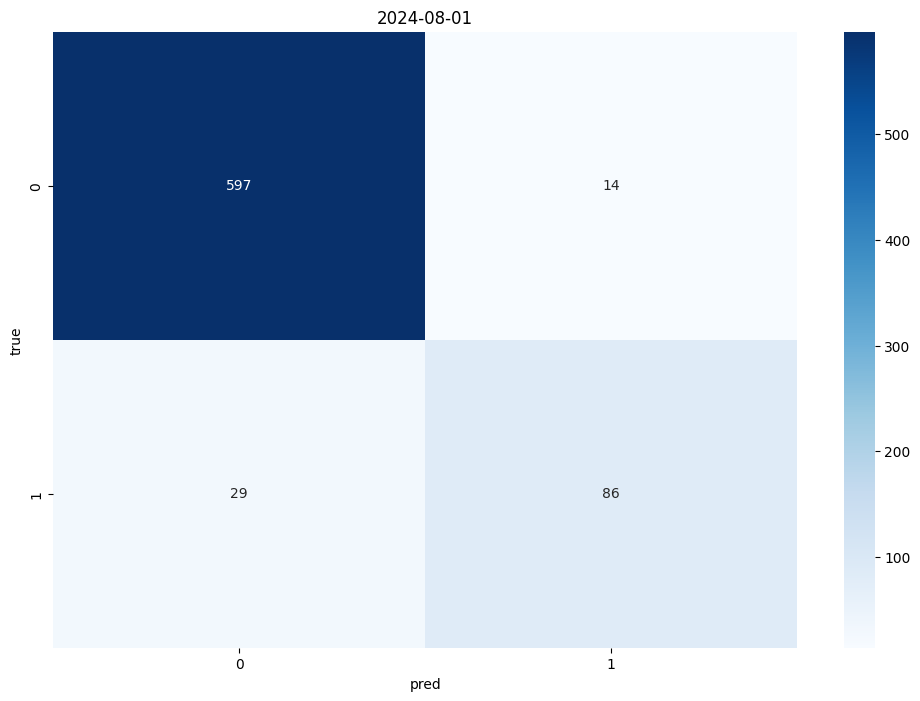

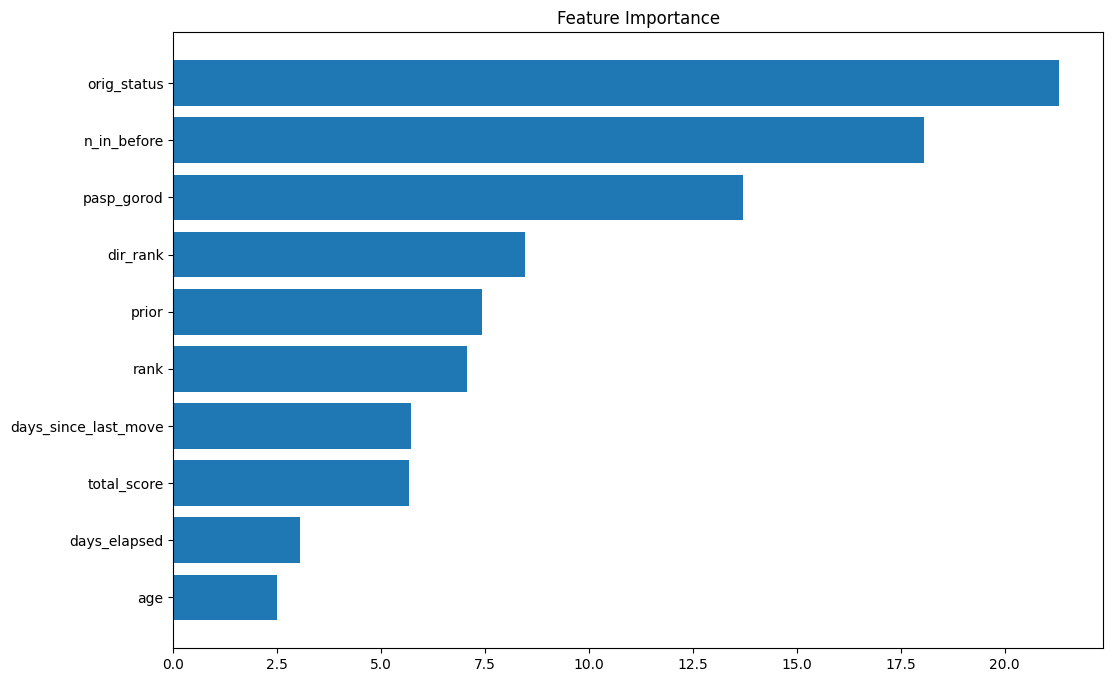

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       605
           1       0.83      0.81      0.82       121

    accuracy                           0.94       726
   macro avg       0.90      0.89      0.89       726
weighted avg       0.94      0.94      0.94       726




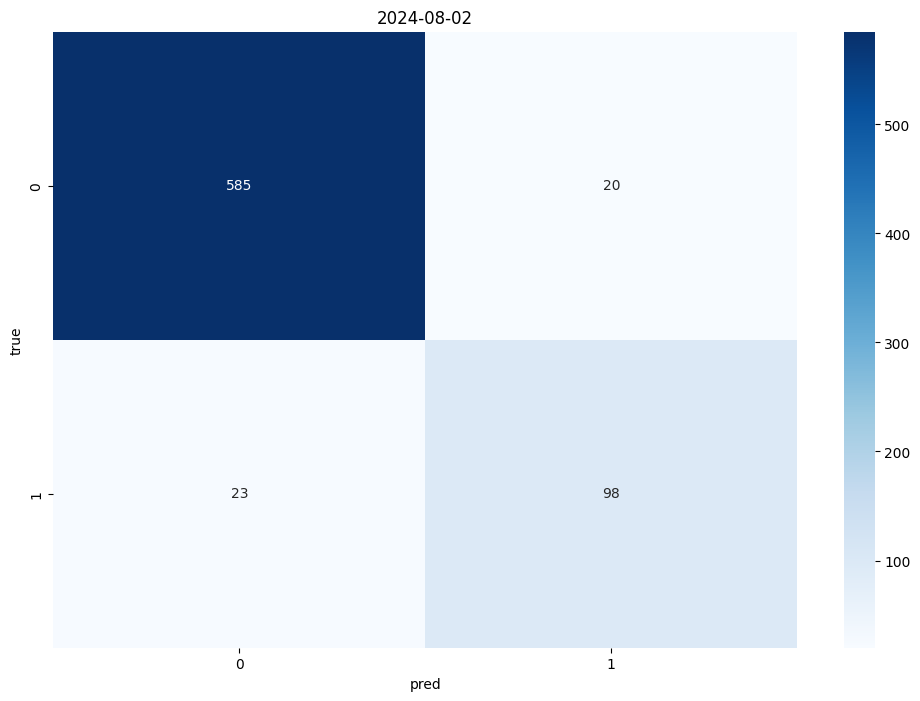

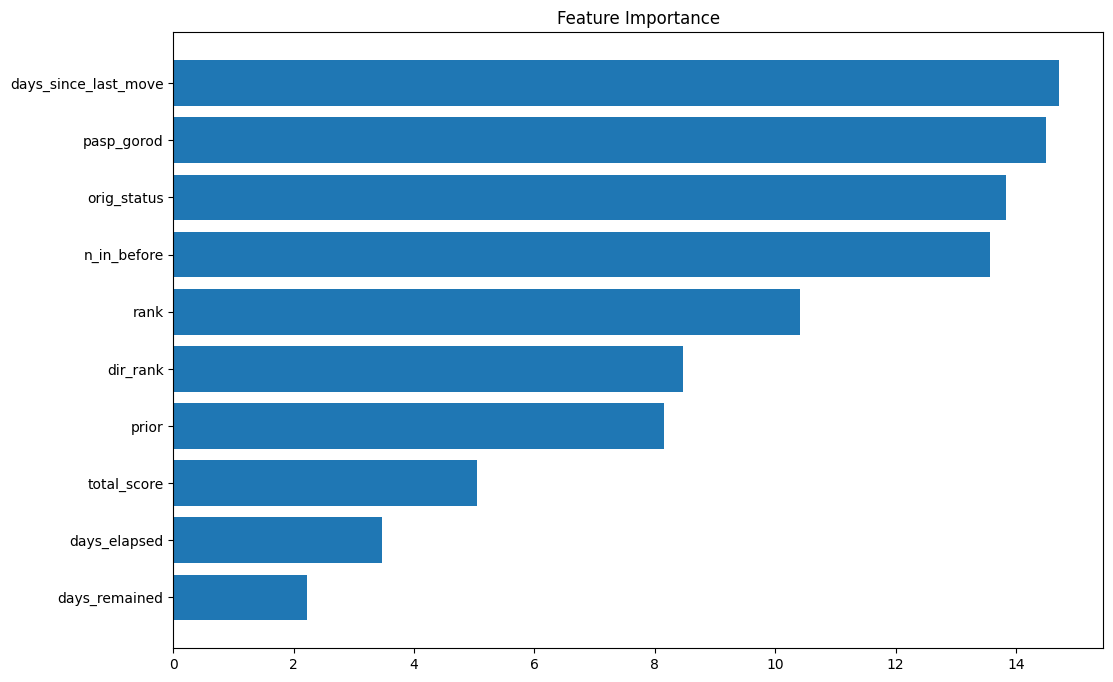

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       604
           1       0.88      0.88      0.88       122

    accuracy                           0.96       726
   macro avg       0.93      0.93      0.93       726
weighted avg       0.96      0.96      0.96       726




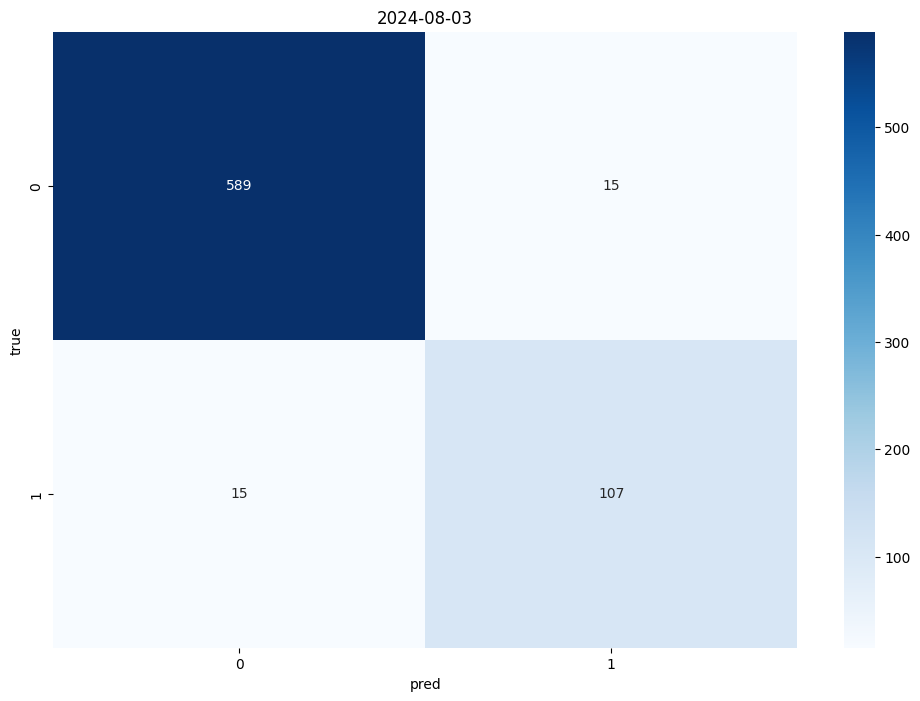

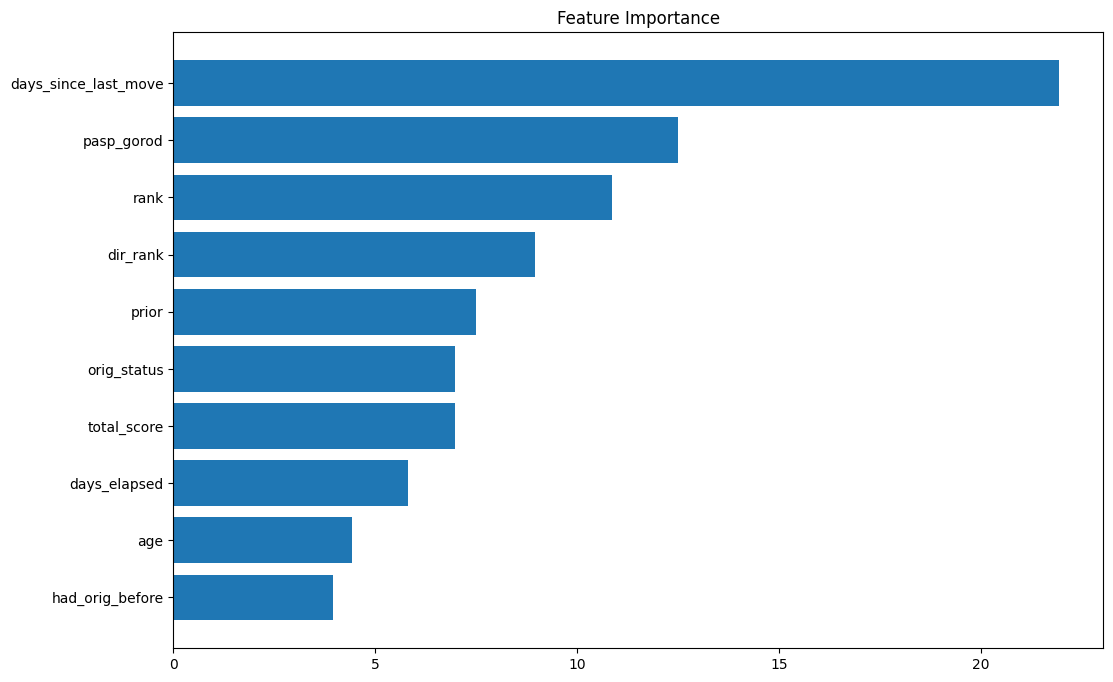

In [35]:
# На скользящем окне в 3 дня
MODELS_3DAY = {}

for idx in range(len(daily_sets)-3):
    train_df = pd.concat(daily_sets[idx:idx+3], ignore_index=True)
    test_df = daily_sets[idx+3]

    X_train = train_df[feature_cols].copy()
    X_train[cat_cols] = X_train[cat_cols].astype(str)
    y_train = train_df['target']

    X_test = test_df[feature_cols].copy()
    X_test[cat_cols] = X_test[cat_cols].astype(str)
    y_test = test_df['target']

    train_pool = Pool(X_train, y_train, cat_features=cat_cols)
    test_pool = Pool(X_test, y_test, cat_features=cat_cols)

    model = CatBoostClassifier(
        iterations = 1500,
        learning_rate = 0.1,
        subsample = 0.8,
        depth = 3,
        loss_function = "Logloss",
        class_weights = [1, 8],
        eval_metric = "Recall",
        random_state = 42,
        verbose = False,
    )
    model.fit(train_pool)

    y_pred = model.predict(test_pool)
    print(classification_report(y_test, y_pred))
    print()

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{TIMES[idx+4].date().isoformat()}')
    plt.xlabel('pred')
    plt.ylabel('true')
    plt.show()

    importances = model.get_feature_importance(train_pool)
    fi_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
    fi_df = fi_df.sort_values('importance', ascending=False)

    top = fi_df.head(10)[::-1]
    plt.figure(figsize=(12, 8))
    plt.barh(top['feature'], top['importance'])
    plt.title("Feature Importance")
    plt.show()

    MODELS_3DAY[TIMES[idx+4].date().isoformat()] = {"model": model, "cm": cm}

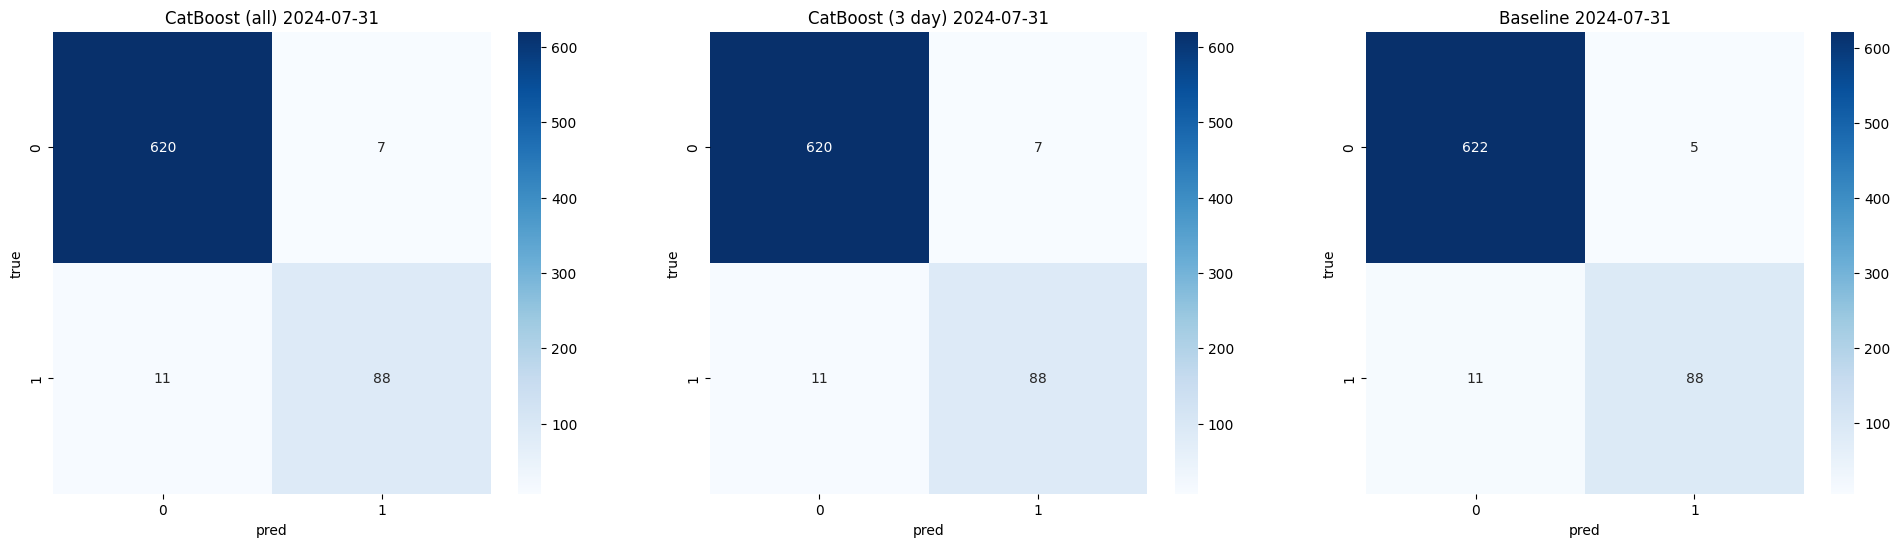

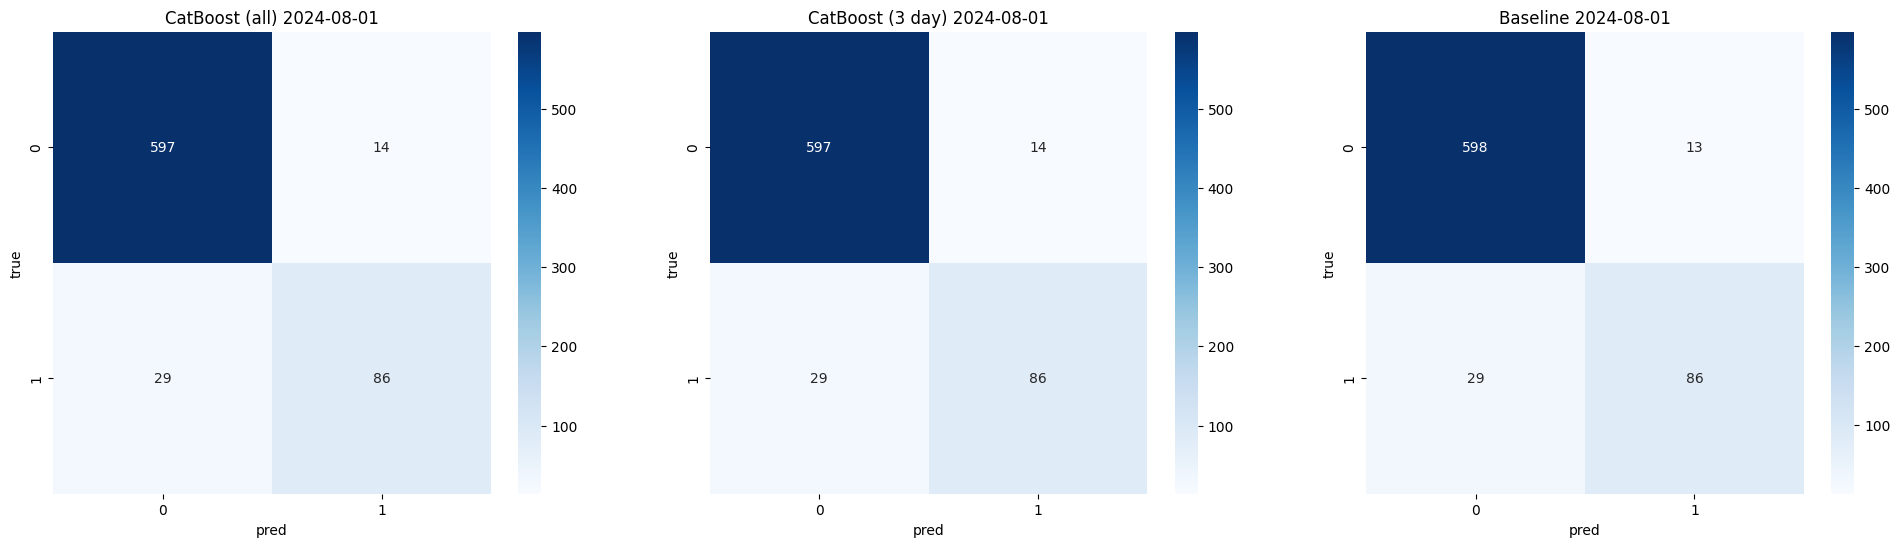

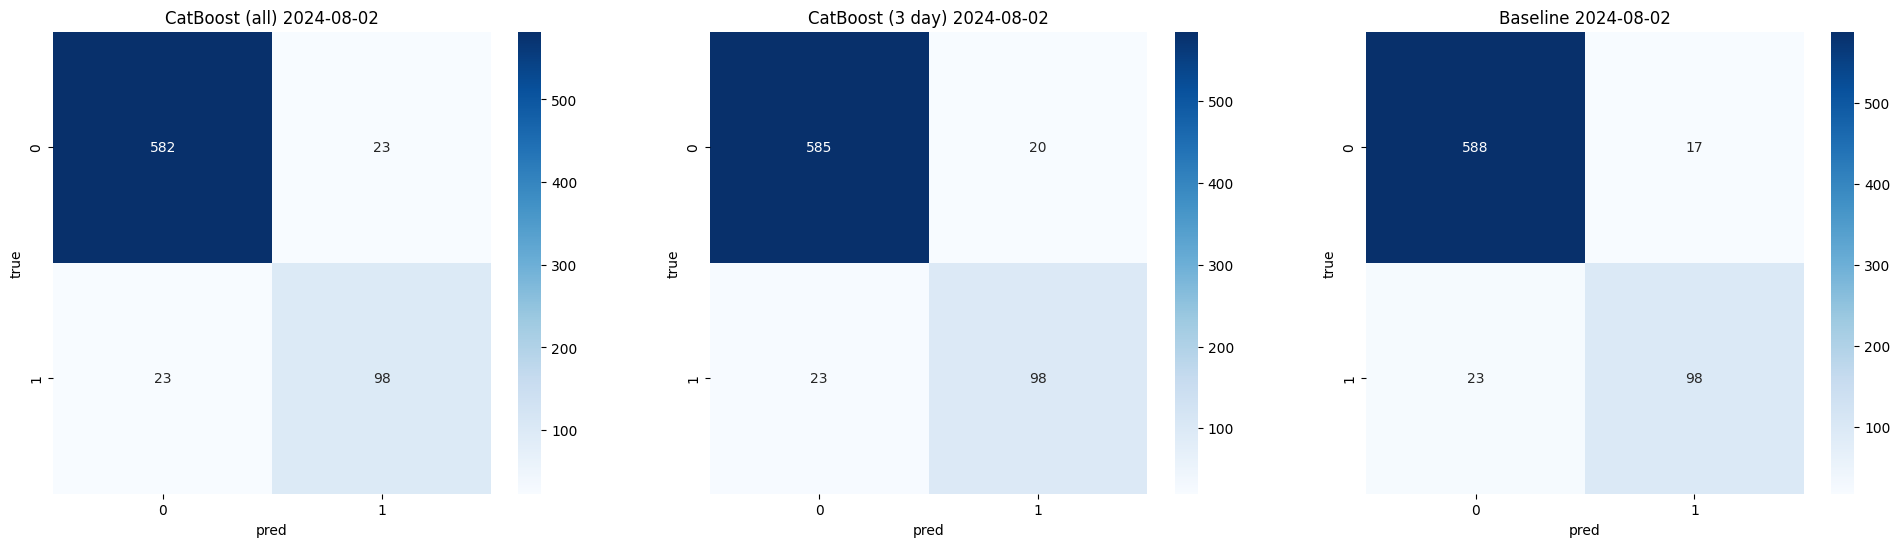

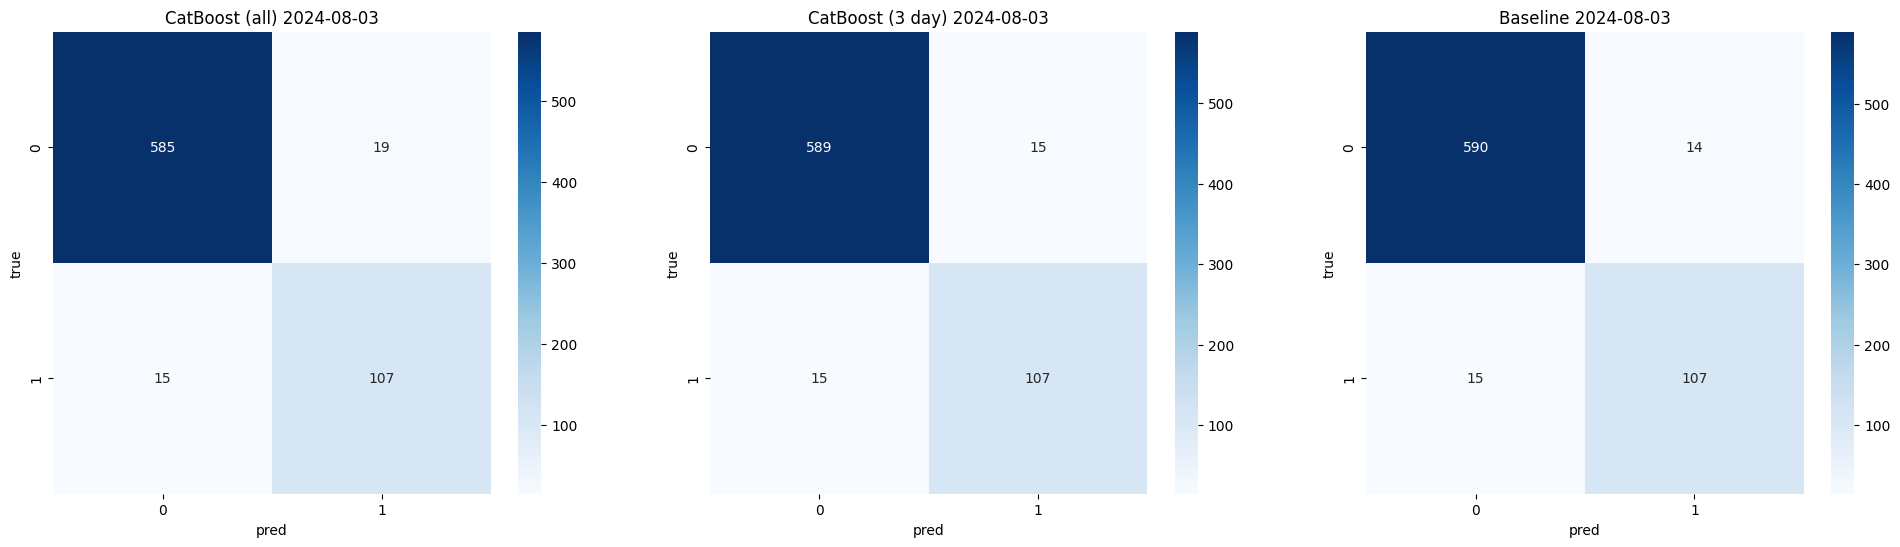

In [36]:
for idx in MODELS_3DAY.keys():
    cm_cb = MODELS[idx]['cm']
    cm_3d = MODELS_3DAY[idx]['cm']
    cm_base = baseline[idx]

    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    sns.heatmap(cm_cb, annot=True, fmt='d', ax=axes[0], cmap='Blues')
    axes[0].set_title(f'CatBoost (all) {idx}')
    axes[0].set_xlabel('pred')
    axes[0].set_ylabel('true')
    sns.heatmap(cm_3d, annot=True, fmt='d', ax=axes[1], cmap='Blues')
    axes[1].set_title(f'CatBoost (3 day) {idx}')
    axes[1].set_xlabel('pred')
    axes[1].set_ylabel('true')
    sns.heatmap(cm_base, annot=True, fmt='d', ax=axes[2], cmap='Blues')
    axes[2].set_title(f'Baseline {idx}')
    axes[2].set_xlabel('pred')
    axes[2].set_ylabel('true')
    plt.show()

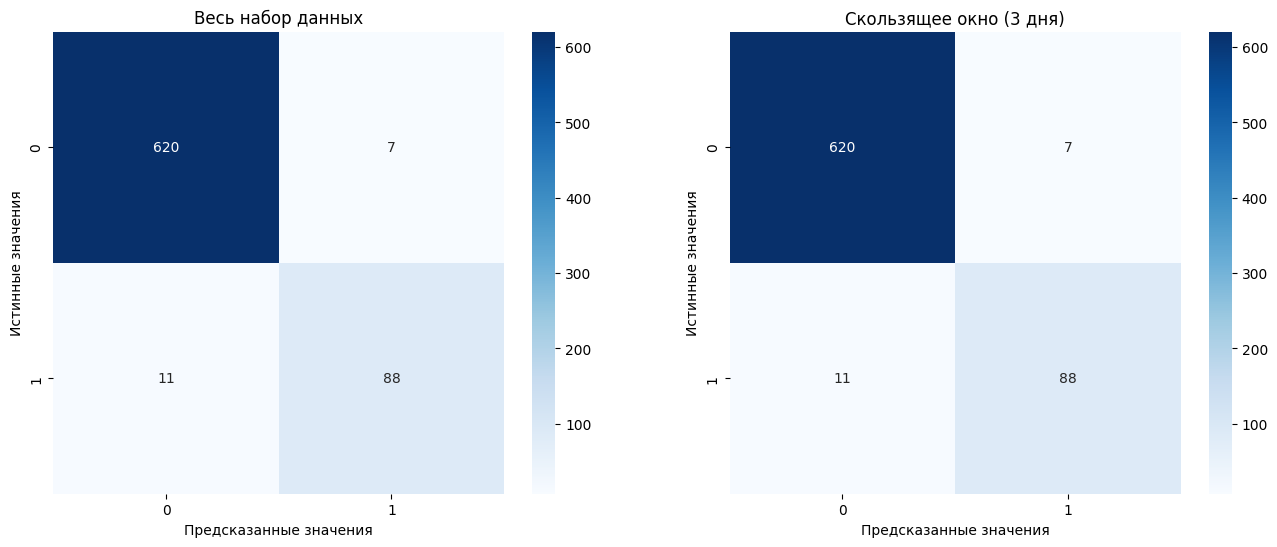

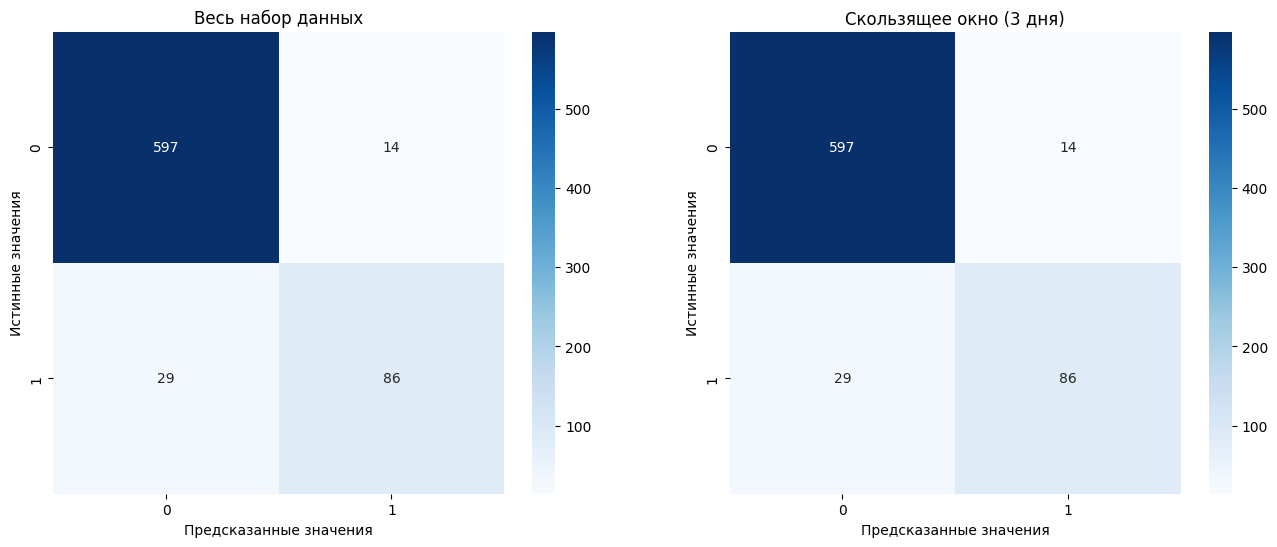

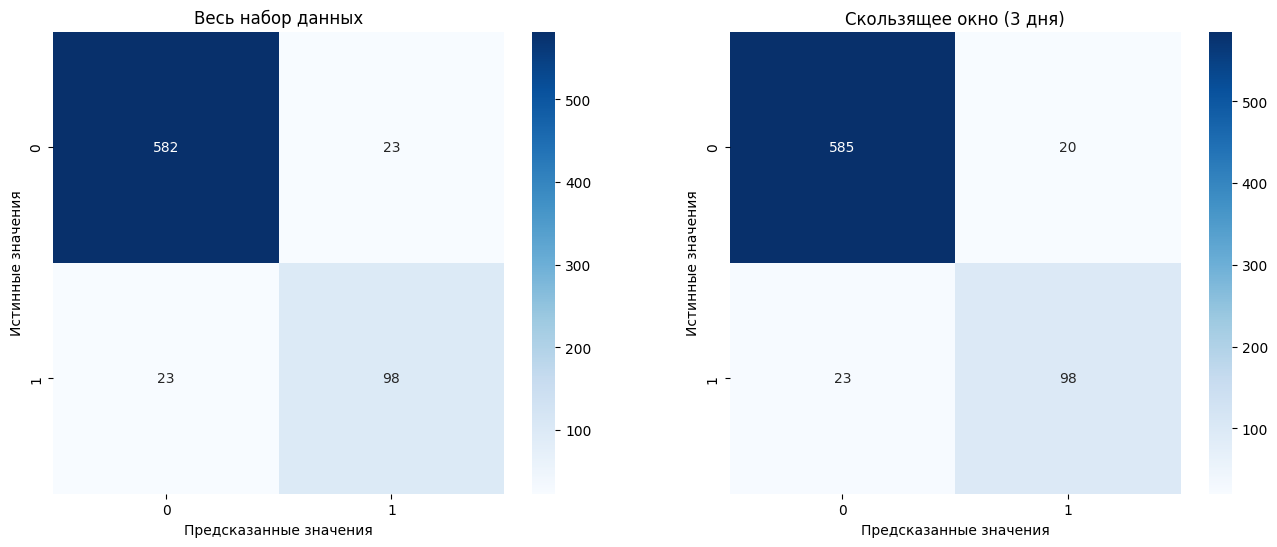

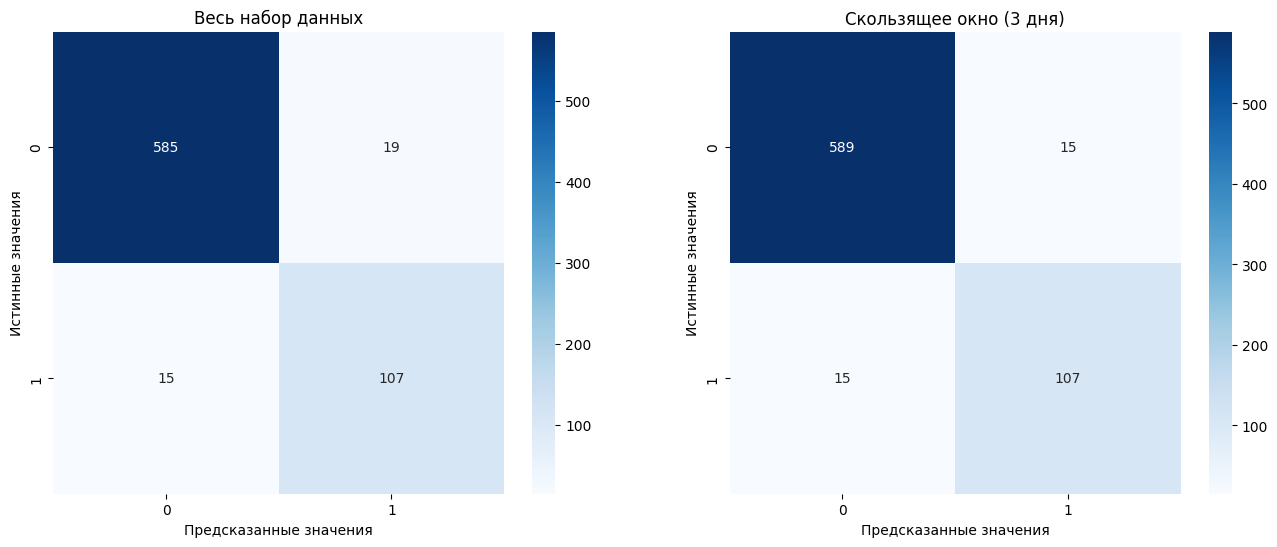

In [41]:
for idx in MODELS_3DAY.keys():
    cm_cb = MODELS[idx]['cm']
    cm_3d = MODELS_3DAY[idx]['cm']
    cm_base = baseline[idx]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm_cb, annot=True, fmt='d', ax=axes[0], cmap='Blues')
    axes[0].set_title(f'Весь набор данных')
    axes[0].set_xlabel('Предсказанные значения')
    axes[0].set_ylabel('Истинные значения')
    sns.heatmap(cm_3d, annot=True, fmt='d', ax=axes[1], cmap='Blues')
    axes[1].set_title(f'Скользящее окно (3 дня)')
    axes[1].set_xlabel('Предсказанные значения')
    axes[1].set_ylabel('Истинные значения')
    plt.show()

In [141]:
daily_sets = []
for idx in range(len(TIMES) - 1):
    df_day = build_df('Прикладная математика и информатика', TIMES[idx], TIMES[idx+1])
    df_day['days_elapsed'] = len(daily_sets) + 1
    df_day['days_remained'] = 7 - len(daily_sets)
    daily_sets.append(df_day)

contest_3day = None
for idx in range(3, len(daily_sets)):
    df_day = daily_sets[idx]

    X_day = df_day[feature_cols].copy()
    X_day[cat_cols] = X_day[cat_cols].astype(str)
    test = Pool(X_day, cat_features=cat_cols)

    model = MODELS_3DAY[TIMES[idx+1].date().isoformat()]['model']

    df_day[f'y_{idx+1}'] = df_day['target']
    df_day[f'pred_{idx+1}'] = model.predict(test)
    df_day[f'prob_{idx+1}'] = model.predict_proba(test)[:, 1]

    keep = ['dir_rank', 'abitur_kod', 'total_score', f'y_{idx+1}', f'pred_{idx+1}', f'prob_{idx+1}']

    if contest_3day is None:
        contest_3day = df_day[keep]
    else:
        if idx != len(daily_sets) - 1:
            contest_3day = contest_3day.merge(df_day[keep], on=['dir_rank', 'abitur_kod', 'total_score'])
        else:
            contest_3day = contest_3day.merge(df_day[keep + ['passes_now']], on=['dir_rank', 'abitur_kod', 'total_score'])

contest_3day = contest_3day.sort_values('dir_rank').reset_index(drop=True)

In [142]:
contest_3day.head(25)

,dir_rank,abitur_kod,total_score,y_4,pred_4,prob_4,y_5,pred_5,prob_5,y_6,pred_6,prob_6,y_7,pred_7,prob_7,passes_now
0,1,659563,99.000000,0,0,0.003830,0,0,0.000109,0,0,0.000764,0,0,0.000532,0
1,2,660134,98.833333,0,0,0.000597,0,0,0.000300,0,0,0.029739,0,0,0.017914,0
2,3,650853,97.333333,0,0,0.001420,0,0,0.006321,0,0,0.005603,0,0,0.000461,0
3,4,654183,97.083333,0,0,0.001109,0,0,0.001458,0,0,0.002146,0,0,0.005573,0
4,5,654498,96.666667,0,0,0.002334,0,0,0.000115,0,0,0.005484,0,0,0.000501,0
5,6,655133,96.666667,0,0,0.000699,0,0,0.001927,0,0,0.002195,0,0,0.008466,0
6,7,649335,96.583333,0,0,0.002158,0,0,0.000148,0,0,0.001497,0,0,0.000115,0
7,8,651721,95.000000,0,0,0.011436,0,0,0.002559,0,0,0.008307,0,0,0.009327,0
8,9,656946,95.000000,1,0,0.000751,1,1,0.883490,1,1,0.998142,1,1,0.999489,1
9,10,655380,94.333333,0,0,0.020777,0,0,0.017283,0,0,0.053795,0,0,0.018785,0
